In [ ]:
# ==========================================
# STEP 1A: Install required packages in Colab
# ==========================================

import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "torch-geometric",
])

print("torch-geometric installed successfully.")

torch-geometric installed successfully.


In [ ]:
# ==========================================
# STEP 1B: Imports, device, and project paths
# ==========================================

import os
import math
import time
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GINConv,
    global_add_pool,
)

warnings.filterwarnings("ignore")

# -------------------------
# Device check
# -------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------
# New experiment directories
# -------------------------
PROJECT_ROOT = Path(
    "/content/graph_level_parent_aware_comparison"
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
LOG_DIR = RESULTS_DIR / "logs"

for directory in [
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    FIG_DIR,
    TABLE_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("Directories created successfully.")

Using device: cuda
GPU: Tesla T4
Project root: /content/graph_level_parent_aware_comparison
Directories created successfully.


In [ ]:
# ==========================================
# STEP 2: Reproducibility and global config
# ==========================================

SEED = 42


def set_seed(seed: int = 42) -> None:
    """
    Set Python, NumPy, and PyTorch random seeds.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

# -------------------------
# Supported graph families
# -------------------------
GRAPH_FAMILIES = [
    "unicyclic",
    "bicyclic",
]

# -------------------------
# Graph-order settings
# -------------------------
N_MIN = 6
N_MAX = 30

# -------------------------
# Original dataset settings
# -------------------------
NUM_UNICYCLIC_PER_ORDER = 200
NUM_BICYCLIC_PER_ORDER = 200

# Maximum structure-preserving transformations
# generated from each original graph
MAX_TRANSFORMS_PER_GRAPH = 2

# -------------------------
# Split settings
# -------------------------
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# -------------------------
# Node-feature settings
# -------------------------
NUM_NODE_FEATURES = 5

NODE_FEATURE_NAMES = [
    "normalized_degree",
    "cycle_membership",
    "pendant_neighbor_count",
    "leaf_indicator",
    "normalized_eccentricity",
]

# -------------------------
# Prediction targets
# -------------------------
TARGET_COLS = [
    "W",
    "MS",
    "Z",
    "M1",
    "M2",
    "R",
]

NUM_TARGETS = len(TARGET_COLS)

print("Configuration initialized successfully.")
print("Seed:", SEED)
print("Graph orders:", N_MIN, "to", N_MAX)
print(
    "Original graphs requested per order:",
    NUM_UNICYCLIC_PER_ORDER,
    "unicyclic +",
    NUM_BICYCLIC_PER_ORDER,
    "bicyclic",
)
print("Maximum transformations per original:", MAX_TRANSFORMS_PER_GRAPH)
print("Split ratios:", TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
print("Node features:", NUM_NODE_FEATURES)
print("Targets:", TARGET_COLS)

Configuration initialized successfully.
Seed: 42
Graph orders: 6 to 30
Original graphs requested per order: 200 unicyclic + 200 bicyclic
Maximum transformations per original: 2
Split ratios: 0.7 0.15 0.15
Node features: 5
Targets: ['W', 'MS', 'Z', 'M1', 'M2', 'R']


In [ ]:
# ==========================================
# STEP 3: Graph validation and hashing
# ==========================================

from networkx.algorithms.graph_hashing import (
    weisfeiler_lehman_graph_hash,
)


def cyclomatic_number(G: nx.Graph) -> int:
    """
    Compute the cyclomatic number of a connected graph:

        μ(G) = m - n + 1
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    return m - n + 1


def is_simple_connected_graph(G: nx.Graph) -> bool:
    """
    Check whether G is a nonempty, simple, connected,
    undirected graph.
    """
    if G.number_of_nodes() == 0:
        return False

    if any(u == v for u, v in G.edges()):
        return False

    if not nx.is_connected(G):
        return False

    return True


def is_unicyclic_graph(G: nx.Graph) -> bool:
    """
    A connected graph is unicyclic when μ(G) = 1.
    """
    return (
        is_simple_connected_graph(G)
        and cyclomatic_number(G) == 1
    )


def is_bicyclic_graph(G: nx.Graph) -> bool:
    """
    A connected graph is bicyclic when μ(G) = 2.
    """
    return (
        is_simple_connected_graph(G)
        and cyclomatic_number(G) == 2
    )


def graph_hash_key(G: nx.Graph) -> str:
    """
    Compute the Weisfeiler–Lehman graph hash used in the
    original notebook for duplicate control.
    """
    return weisfeiler_lehman_graph_hash(G)


def graph_family_label(G: nx.Graph) -> str:
    """
    Infer the supported synthetic graph family.
    """
    if is_unicyclic_graph(G):
        return "unicyclic"

    if is_bicyclic_graph(G):
        return "bicyclic"

    return "unknown"


# -------------------------
# Basic validation test
# -------------------------
G_u_test = nx.cycle_graph(6)

G_b_test = nx.Graph()
G_b_test.add_edges_from([
    (0, 1),
    (1, 2),
    (2, 0),
    (2, 3),
    (3, 4),
    (4, 2),
])

print(
    "Unicyclic mu:",
    cyclomatic_number(G_u_test),
    "| valid:",
    is_unicyclic_graph(G_u_test),
)

print(
    "Bicyclic mu:",
    cyclomatic_number(G_b_test),
    "| valid:",
    is_bicyclic_graph(G_b_test),
)

print(
    "Unicyclic family:",
    graph_family_label(G_u_test),
)

print(
    "Bicyclic family:",
    graph_family_label(G_b_test),
)

print(
    "Hash sample:",
    graph_hash_key(G_u_test),
)

Unicyclic mu: 1 | valid: True
Bicyclic mu: 2 | valid: True
Unicyclic family: unicyclic
Bicyclic family: bicyclic
Hash sample: 6de89950f00660d47a6a47b68a218b4c


In [ ]:
# ==========================================
# STEP 4: Unicyclic and bicyclic generators
# ==========================================

def generate_unicyclic_graph(
    n: int,
    rng: np.random.Generator = None,
) -> nx.Graph:
    """
    Generate one random unicyclic graph of order n.
    """
    if rng is None:
        rng = np.random.default_rng()

    if n < 3:
        raise ValueError(
            "Unicyclic graph requires n >= 3."
        )

    # Randomly select the cycle length.
    cycle_length = int(
        rng.integers(3, n + 1)
    )

    # Construct the initial cycle.
    G = nx.cycle_graph(cycle_length)

    # Attach remaining vertices as tree extensions.
    next_node = cycle_length

    while G.number_of_nodes() < n:
        attach_to = int(
            rng.choice(list(G.nodes()))
        )

        G.add_node(next_node)
        G.add_edge(next_node, attach_to)

        next_node += 1

    if not is_unicyclic_graph(G):
        raise RuntimeError(
            "Generated graph is not unicyclic."
        )

    return G


def make_vertex_sharing_core(
    l1: int,
    l2: int,
) -> nx.Graph:
    """
    Construct two cycles sharing exactly one vertex.
    """
    G = nx.Graph()

    cycle1 = list(range(l1))

    for i in range(l1):
        G.add_edge(
            cycle1[i],
            cycle1[(i + 1) % l1],
        )

    # The second cycle shares vertex 0.
    start = l1

    cycle2_new = list(
        range(start, start + l2 - 1)
    )

    cycle2 = [0] + cycle2_new

    for i in range(l2):
        G.add_edge(
            cycle2[i],
            cycle2[(i + 1) % l2],
        )

    return G


def make_edge_sharing_core(
    l1: int,
    l2: int,
) -> nx.Graph:
    """
    Construct two cycles sharing the edge (0, 1).
    """
    G = nx.Graph()

    cycle1 = list(range(l1))

    for i in range(l1):
        G.add_edge(
            cycle1[i],
            cycle1[(i + 1) % l1],
        )

    start = l1

    cycle2_new = list(
        range(start, start + l2 - 2)
    )

    cycle2 = [0, 1] + cycle2_new

    for i in range(l2):
        G.add_edge(
            cycle2[i],
            cycle2[(i + 1) % l2],
        )

    return G


def make_bridge_connected_core(
    l1: int,
    l2: int,
) -> nx.Graph:
    """
    Construct two disjoint cycles joined by one bridge.
    """
    G = nx.Graph()

    cycle1 = list(range(l1))

    for i in range(l1):
        G.add_edge(
            cycle1[i],
            cycle1[(i + 1) % l1],
        )

    start = l1
    cycle2 = list(
        range(start, start + l2)
    )

    for i in range(l2):
        G.add_edge(
            cycle2[i],
            cycle2[(i + 1) % l2],
        )

    G.add_edge(
        cycle1[0],
        cycle2[0],
    )

    return G


def generate_bicyclic_graph(
    n: int,
    rng: np.random.Generator = None,
) -> nx.Graph:
    """
    Generate one random bicyclic graph of order n.
    """
    if rng is None:
        rng = np.random.default_rng()

    if n < 4:
        raise ValueError(
            "Bicyclic graph requires n >= 4."
        )

    core_types = [
        "vertex-sharing",
        "edge-sharing",
        "bridge-connected",
    ]

    max_attempts = 200

    for _ in range(max_attempts):
        core_type = str(
            rng.choice(core_types)
        )

        if core_type == "vertex-sharing":
            possible = [
                (l1, l2)
                for l1 in range(3, n + 1)
                for l2 in range(3, n + 1)
                if (l1 + l2 - 1) <= n
            ]

            l1, l2 = possible[
                int(rng.integers(len(possible)))
            ]

            G = make_vertex_sharing_core(
                l1,
                l2,
            )

        elif core_type == "edge-sharing":
            possible = [
                (l1, l2)
                for l1 in range(3, n + 1)
                for l2 in range(3, n + 1)
                if (l1 + l2 - 2) <= n
            ]

            l1, l2 = possible[
                int(rng.integers(len(possible)))
            ]

            G = make_edge_sharing_core(
                l1,
                l2,
            )

        else:
            possible = [
                (l1, l2)
                for l1 in range(3, n + 1)
                for l2 in range(3, n + 1)
                if (l1 + l2) <= n
            ]

            # Some small orders cannot support two
            # bridge-connected cycles.
            if not possible:
                continue

            l1, l2 = possible[
                int(rng.integers(len(possible)))
            ]

            G = make_bridge_connected_core(
                l1,
                l2,
            )

        # Attach remaining vertices as pendant extensions.
        next_node = (
            max(G.nodes()) + 1
            if G.number_of_nodes() > 0
            else 0
        )

        while G.number_of_nodes() < n:
            attach_to = int(
                rng.choice(list(G.nodes()))
            )

            G.add_node(next_node)
            G.add_edge(next_node, attach_to)

            next_node += 1

        if is_bicyclic_graph(G):
            return G

    raise RuntimeError(
        "Failed to generate a valid bicyclic graph."
    )


# ------------------------------------------
# Deterministic generator validation
# ------------------------------------------
generator_test_rng = np.random.default_rng(SEED)

G_u_generator_test = generate_unicyclic_graph(
    10,
    generator_test_rng,
)

G_b_generator_test = generate_bicyclic_graph(
    10,
    generator_test_rng,
)

print(
    "Unicyclic:",
    G_u_generator_test.number_of_nodes(),
    G_u_generator_test.number_of_edges(),
    cyclomatic_number(G_u_generator_test),
    is_unicyclic_graph(G_u_generator_test),
)

print(
    "Bicyclic:",
    G_b_generator_test.number_of_nodes(),
    G_b_generator_test.number_of_edges(),
    cyclomatic_number(G_b_generator_test),
    is_bicyclic_graph(G_b_generator_test),
)

Unicyclic: 10 10 1 True
Bicyclic: 10 11 2 True


In [ ]:
# ==========================================
# STEP 5: Structure-preserving transformations
# ==========================================

def get_leaf_nodes(G: nx.Graph):
    return [
        v
        for v in G.nodes()
        if G.degree(v) == 1
    ]


def get_cycle_nodes_unicyclic(G: nx.Graph):
    cycles = nx.cycle_basis(G)

    if len(cycles) != 1:
        return set()

    return set(cycles[0])


def get_cycle_nodes_bicyclic(G: nx.Graph):
    cycles = nx.cycle_basis(G)

    core_nodes = set()

    for cycle in cycles:
        core_nodes.update(cycle)

    return core_nodes


def get_non_core_components_attached_to_core(
    G: nx.Graph,
    core_nodes: set,
):
    H = G.copy()
    H.remove_nodes_from(core_nodes)

    components_info = []

    for component in nx.connected_components(H):
        component = set(component)

        core_neighbors = set()
        boundary_nodes = set()

        for u in component:
            for v in G.neighbors(u):
                if v in core_nodes:
                    core_neighbors.add(v)
                    boundary_nodes.add(u)

        if (
            len(core_neighbors) == 1
            and len(boundary_nodes) >= 1
        ):
            core_attach = next(
                iter(core_neighbors)
            )

            root = next(
                iter(boundary_nodes)
            )

            components_info.append(
                (
                    core_attach,
                    root,
                    component,
                )
            )

    return components_info


def pendant_edge_relocation_unicyclic(
    G: nx.Graph,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    if not is_unicyclic_graph(G):
        return None

    cycle_nodes = list(
        get_cycle_nodes_unicyclic(G)
    )

    candidate_leaves = []

    for leaf in get_leaf_nodes(G):
        neighbor = next(
            iter(G.neighbors(leaf))
        )

        if neighbor in cycle_nodes:
            candidate_leaves.append(
                (leaf, neighbor)
            )

    if not candidate_leaves:
        return None

    leaf, source = candidate_leaves[
        int(rng.integers(len(candidate_leaves)))
    ]

    possible_targets = [
        target
        for target in cycle_nodes
        if (
            target != source
            and not G.has_edge(leaf, target)
        )
    ]

    if not possible_targets:
        return None

    target = possible_targets[
        int(rng.integers(len(possible_targets)))
    ]

    H = G.copy()
    H.remove_edge(source, leaf)
    H.add_edge(target, leaf)

    return H if is_unicyclic_graph(H) else None


def pendant_subtree_reattachment_unicyclic(
    G: nx.Graph,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    if not is_unicyclic_graph(G):
        return None

    cycle_nodes = list(
        get_cycle_nodes_unicyclic(G)
    )

    candidate_roots = []

    for source in cycle_nodes:
        for neighbor in G.neighbors(source):
            if neighbor not in cycle_nodes:
                candidate_roots.append(
                    (source, neighbor)
                )

    if not candidate_roots:
        return None

    source, root = candidate_roots[
        int(rng.integers(len(candidate_roots)))
    ]

    possible_targets = [
        target
        for target in cycle_nodes
        if (
            target != source
            and not G.has_edge(root, target)
        )
    ]

    if not possible_targets:
        return None

    target = possible_targets[
        int(rng.integers(len(possible_targets)))
    ]

    H = G.copy()
    H.remove_edge(source, root)
    H.add_edge(target, root)

    return H if is_unicyclic_graph(H) else None


def pendant_relocation_bicyclic(
    G: nx.Graph,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    if not is_bicyclic_graph(G):
        return None

    core_nodes = get_cycle_nodes_bicyclic(G)

    attached_components = (
        get_non_core_components_attached_to_core(
            G,
            core_nodes,
        )
    )

    if not attached_components:
        return None

    source, root, component_nodes = (
        attached_components[
            int(rng.integers(
                len(attached_components)
            ))
        ]
    )

    possible_targets = [
        target
        for target in core_nodes
        if (
            target != source
            and not G.has_edge(root, target)
        )
    ]

    if not possible_targets:
        return None

    target = possible_targets[
        int(rng.integers(len(possible_targets)))
    ]

    H = G.copy()
    H.remove_edge(source, root)
    H.add_edge(target, root)

    return H if is_bicyclic_graph(H) else None


def core_preserving_rewiring_bicyclic(
    G: nx.Graph,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    if not is_bicyclic_graph(G):
        return None

    core_nodes = get_cycle_nodes_bicyclic(G)

    candidates = []

    attached_components = (
        get_non_core_components_attached_to_core(
            G,
            core_nodes,
        )
    )

    for source, root, component_nodes in attached_components:
        candidates.append(
            (source, root)
        )

    if not candidates:
        return None

    source, root = candidates[
        int(rng.integers(len(candidates)))
    ]

    possible_targets = [
        target
        for target in core_nodes
        if (
            target != source
            and not G.has_edge(root, target)
        )
    ]

    if not possible_targets:
        return None

    target = possible_targets[
        int(rng.integers(len(possible_targets)))
    ]

    H = G.copy()
    H.remove_edge(source, root)
    H.add_edge(target, root)

    return H if is_bicyclic_graph(H) else None


def generate_valid_transformations(
    G: nx.Graph,
    max_transforms: int = 2,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    transformations = []
    seen_local = set()

    original_hash = graph_hash_key(G)

    if is_unicyclic_graph(G):
        operations = [
            pendant_edge_relocation_unicyclic,
            pendant_subtree_reattachment_unicyclic,
        ]

    elif is_bicyclic_graph(G):
        operations = [
            pendant_relocation_bicyclic,
            core_preserving_rewiring_bicyclic,
        ]

    else:
        return transformations

    attempts = 0
    maximum_attempts = (
        50 * max_transforms
    )

    while (
        len(transformations) < max_transforms
        and attempts < maximum_attempts
    ):
        operation = operations[
            int(rng.integers(len(operations)))
        ]

        H = operation(
            G,
            rng,
        )

        attempts += 1

        if H is None:
            continue

        transformed_hash = graph_hash_key(H)

        if (
            transformed_hash == original_hash
            or transformed_hash in seen_local
        ):
            continue

        seen_local.add(
            transformed_hash
        )

        transformations.append(H)

    return transformations


# ------------------------------------------
# Deterministic transformation validation
# ------------------------------------------
transformation_test_rng = np.random.default_rng(
    SEED
)

G_u_transform_test = generate_unicyclic_graph(
    10,
    transformation_test_rng,
)

transformed_unicyclic = generate_valid_transformations(
    G_u_transform_test,
    max_transforms=2,
    rng=transformation_test_rng,
)

G_b_transform_test = generate_bicyclic_graph(
    10,
    transformation_test_rng,
)

transformed_bicyclic = generate_valid_transformations(
    G_b_transform_test,
    max_transforms=2,
    rng=transformation_test_rng,
)

print(
    "Unicyclic transforms:",
    len(transformed_unicyclic),
    [
        is_unicyclic_graph(H)
        for H in transformed_unicyclic
    ],
)

print(
    "Bicyclic transforms:",
    len(transformed_bicyclic),
    [
        is_bicyclic_graph(H)
        for H in transformed_bicyclic
    ],
)

Unicyclic transforms: 2 [True, True]
Bicyclic transforms: 0 []


In [ ]:
# ==========================================
# STEP 6: Unified synthetic dataset builder
# ==========================================

def make_graph_record(
    graph_id: int,
    G: nx.Graph,
    family: str,
    is_transformed: int = 0,
    parent_graph_id: int = None,
):
    return {
        "graph_id": graph_id,
        "graph": G,
        "family": family,
        "order": G.number_of_nodes(),
        "is_transformed": int(is_transformed),
        "parent_graph_id": parent_graph_id,
        "graph_hash": graph_hash_key(G),
    }


def build_synthetic_family_records(
    family_name: str,
    n_min: int,
    n_max: int,
    num_graphs_per_order: int,
    max_transforms_per_graph: int = 2,
    seed: int = 42,
    start_graph_id: int = 0,
):
    """
    Build records for one synthetic family: unicyclic or bicyclic.
    """
    rng = np.random.default_rng(seed)

    records = []
    seen_hashes = set()
    graph_id = start_graph_id

    stats = {
        "family": family_name,
        "original_kept": 0,
        "transformed_kept": 0,
        "duplicates_skipped": 0,
        "transform_duplicates_skipped": 0,
    }

    if family_name == "unicyclic":
        generator_fn = generate_unicyclic_graph
        validator_fn = is_unicyclic_graph

    elif family_name == "bicyclic":
        generator_fn = generate_bicyclic_graph
        validator_fn = is_bicyclic_graph

    else:
        raise ValueError(
            "Only 'unicyclic' or 'bicyclic' allowed here."
        )

    for n in range(n_min, n_max + 1):
        for _ in range(num_graphs_per_order):

            G = generator_fn(n, rng)
            h = graph_hash_key(G)

            if h in seen_hashes:
                stats["duplicates_skipped"] += 1
                continue

            seen_hashes.add(h)

            parent_id = graph_id

            records.append(
                make_graph_record(
                    graph_id=graph_id,
                    G=G,
                    family=family_name,
                    is_transformed=0,
                    parent_graph_id=None,
                )
            )

            stats["original_kept"] += 1
            graph_id += 1

            transformed_graphs = (
                generate_valid_transformations(
                    G,
                    max_transforms=(
                        max_transforms_per_graph
                    ),
                    rng=rng,
                )
            )

            for H in transformed_graphs:

                if not validator_fn(H):
                    continue

                hh = graph_hash_key(H)

                if hh in seen_hashes:
                    stats[
                        "transform_duplicates_skipped"
                    ] += 1
                    continue

                seen_hashes.add(hh)

                records.append(
                    make_graph_record(
                        graph_id=graph_id,
                        G=H,
                        family=family_name,
                        is_transformed=1,
                        parent_graph_id=parent_id,
                    )
                )

                stats["transformed_kept"] += 1
                graph_id += 1

    return records, stats, graph_id


def build_original_master_dataset(
    n_min=N_MIN,
    n_max=N_MAX,
    num_unicyclic_per_order=(
        NUM_UNICYCLIC_PER_ORDER
    ),
    num_bicyclic_per_order=(
        NUM_BICYCLIC_PER_ORDER
    ),
    max_transforms_per_graph=(
        MAX_TRANSFORMS_PER_GRAPH
    ),
    seed=SEED,
):
    """
    Build the original benchmark dataset:
    unicyclic + bicyclic in one master dataset.
    """
    all_records = []
    family_stats = []

    unicyclic_records, unicyclic_stats, next_graph_id = (
        build_synthetic_family_records(
            family_name="unicyclic",
            n_min=n_min,
            n_max=n_max,
            num_graphs_per_order=(
                num_unicyclic_per_order
            ),
            max_transforms_per_graph=(
                max_transforms_per_graph
            ),
            seed=seed,
            start_graph_id=0,
        )
    )

    all_records.extend(
        unicyclic_records
    )

    family_stats.append(
        unicyclic_stats
    )

    bicyclic_records, bicyclic_stats, next_graph_id = (
        build_synthetic_family_records(
            family_name="bicyclic",
            n_min=n_min,
            n_max=n_max,
            num_graphs_per_order=(
                num_bicyclic_per_order
            ),
            max_transforms_per_graph=(
                max_transforms_per_graph
            ),
            seed=seed + 1,
            start_graph_id=next_graph_id,
        )
    )

    all_records.extend(
        bicyclic_records
    )

    family_stats.append(
        bicyclic_stats
    )

    df_meta = pd.DataFrame([
        {
            "graph_id": record["graph_id"],
            "family": record["family"],
            "order": record["order"],
            "is_transformed": (
                record["is_transformed"]
            ),
            "parent_graph_id": (
                record["parent_graph_id"]
            ),
            "graph_hash": (
                record["graph_hash"]
            ),
        }
        for record in all_records
    ])

    return (
        all_records,
        df_meta,
        family_stats,
    )

In [ ]:
# ==========================================
# STEP 7: Generate the master dataset
# ==========================================

generation_start_time = time.time()

dataset_records, df_meta, family_stats = (
    build_original_master_dataset()
)

generation_elapsed = (
    time.time() - generation_start_time
)

print("Total records:", len(dataset_records))

print("\nFamily statistics:")
for stats in family_stats:
    print(stats)

print("\nFamily counts:")
print(
    df_meta["family"].value_counts()
)

print("\nOriginal/transformed counts:")
print(
    df_meta["is_transformed"].value_counts()
)

print(
    "\nUnique hashes:",
    df_meta["graph_hash"].nunique(),
)

print(
    "Total rows:",
    len(df_meta),
)

assert (
    df_meta["graph_hash"].nunique()
    == len(df_meta)
), "Duplicate graph hashes found."

assert (
    set(df_meta["family"].unique())
    == {"unicyclic", "bicyclic"}
), "Unexpected graph family found."

assert (
    df_meta["graph_id"].nunique()
    == len(df_meta)
), "Duplicate graph IDs found."

print("\nDuplicate check passed.")
print(
    f"Dataset generation time: "
    f"{generation_elapsed:.2f} seconds"
)

Total records: 19180

Family statistics:
{'family': 'unicyclic', 'original_kept': 3324, 'transformed_kept': 6106, 'duplicates_skipped': 1676, 'transform_duplicates_skipped': 361}
{'family': 'bicyclic', 'original_kept': 3449, 'transformed_kept': 6301, 'duplicates_skipped': 1551, 'transform_duplicates_skipped': 324}

Family counts:
family
bicyclic     9750
unicyclic    9430
Name: count, dtype: int64

Original/transformed counts:
is_transformed
1    12407
0     6773
Name: count, dtype: int64

Unique hashes: 19180
Total rows: 19180

Duplicate check passed.
Dataset generation time: 38.24 seconds


In [ ]:
# ==========================================
# STEP 8: Exact topological-index computation
# ==========================================

def canonical_graph_signature(G: nx.Graph):
    """
    Canonical immutable signature for memoization.
    """
    nodes = sorted(G.nodes())
    mapping = {
        node: index
        for index, node in enumerate(nodes)
    }

    edges = sorted(
        (
            min(mapping[u], mapping[v]),
            max(mapping[u], mapping[v]),
        )
        for u, v in G.edges()
    )

    return (
        len(nodes),
        tuple(edges),
    )


# -------------------------
# Wiener index
# -------------------------
def wiener_index(G: nx.Graph) -> int:
    lengths = dict(
        nx.all_pairs_shortest_path_length(G)
    )

    total = 0
    nodes = list(G.nodes())

    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            total += lengths[u][v]

    return total


# -------------------------
# First Zagreb index
# -------------------------
def first_zagreb_index(G: nx.Graph) -> int:
    return sum(
        G.degree(v) ** 2
        for v in G.nodes()
    )


# -------------------------
# Second Zagreb index
# -------------------------
def second_zagreb_index(G: nx.Graph) -> int:
    return sum(
        G.degree(u) * G.degree(v)
        for u, v in G.edges()
    )


# -------------------------
# Randic index
# -------------------------
def randic_index(G: nx.Graph) -> float:
    return sum(
        1.0
        / math.sqrt(
            G.degree(u) * G.degree(v)
        )
        for u, v in G.edges()
    )


# -------------------------
# Merrifield-Simmons index
# Number of independent sets
# -------------------------
_ms_cache = {}


def merrifield_simmons_index(
    G: nx.Graph,
) -> int:
    signature = canonical_graph_signature(G)

    if signature in _ms_cache:
        return _ms_cache[signature]

    number_of_nodes = G.number_of_nodes()

    if number_of_nodes == 0:
        return 1

    if number_of_nodes == 1:
        return 2

    vertex = next(iter(G.nodes()))

    G_excluded = G.copy()
    G_excluded.remove_node(vertex)

    G_included = G.copy()
    neighbors = list(G.neighbors(vertex))

    G_included.remove_nodes_from(
        [vertex] + neighbors
    )

    result = (
        merrifield_simmons_index(G_excluded)
        + merrifield_simmons_index(G_included)
    )

    _ms_cache[signature] = result

    return result


# -------------------------
# Hosoya index
# Number of matchings
# -------------------------
_z_cache = {}


def hosoya_index(G: nx.Graph) -> int:
    signature = canonical_graph_signature(G)

    if signature in _z_cache:
        return _z_cache[signature]

    if G.number_of_edges() == 0:
        return 1

    u, v = next(iter(G.edges()))

    G_excluded = G.copy()
    G_excluded.remove_edge(u, v)

    G_included = G.copy()
    G_included.remove_nodes_from(
        [u, v]
    )

    result = (
        hosoya_index(G_excluded)
        + hosoya_index(G_included)
    )

    _z_cache[signature] = result

    return result


# -------------------------
# Complete target vector
# -------------------------
def compute_exact_target_vector(
    G: nx.Graph,
):
    """
    Return:
    [W, MS, Z, M1, M2, R]
    """
    W = wiener_index(G)
    MS = merrifield_simmons_index(G)
    Z = hosoya_index(G)
    M1 = first_zagreb_index(G)
    M2 = second_zagreb_index(G)
    R = randic_index(G)

    return np.array(
        [W, MS, Z, M1, M2, R],
        dtype=float,
    )


# -------------------------
# Small correctness test
# -------------------------
G_index_test = nx.cycle_graph(6)

test_targets = compute_exact_target_vector(
    G_index_test
)

print(
    "Target order:",
    TARGET_COLS,
)

print(
    "C6 target vector:",
    test_targets,
)

assert len(test_targets) == 6
assert np.isfinite(test_targets).all()

print(
    "Exact-index functions validated successfully."
)

Target order: ['W', 'MS', 'Z', 'M1', 'M2', 'R']
C6 target vector: [27. 18. 18. 24. 24.  3.]
Exact-index functions validated successfully.


In [ ]:
# ==========================================
# STEP 9: Fast sequential exact labeling
#         with checkpoint and resume
# ==========================================

import gc

LABEL_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "bounded_exact_labels_checkpoint.csv"
)

LABEL_SAVE_INTERVAL = 500
GC_INTERVAL = 1000


def save_label_checkpoint(
    completed_rows,
    output_path,
):
    """
    Save completed labels atomically.
    """
    checkpoint_df = (
        pd.DataFrame(completed_rows)
        .sort_values("graph_id")
        .reset_index(drop=True)
    )

    temporary_path = output_path.with_suffix(
        ".tmp.csv"
    )

    checkpoint_df.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        output_path
    )


def load_existing_label_checkpoint(
    checkpoint_path,
):
    """
    Load completed labels for checkpoint resume.
    """
    if not checkpoint_path.exists():
        return [], set()

    existing_df = pd.read_csv(
        checkpoint_path
    )

    completed_rows = (
        existing_df
        .sort_values("graph_id")
        .to_dict("records")
    )

    completed_ids = set(
        existing_df["graph_id"]
        .astype(int)
        .tolist()
    )

    return completed_rows, completed_ids


def label_master_dataset_fast(
    records,
    checkpoint_path,
    save_interval=500,
    gc_interval=1000,
):
    """
    Compute the same six exact labels as the original
    notebook while retaining checkpoint/resume support.
    """
    completed_rows, completed_ids = (
        load_existing_label_checkpoint(
            checkpoint_path
        )
    )

    total_graphs = len(records)
    initial_completed = len(completed_ids)

    print(
        f"Existing completed labels: "
        f"{initial_completed:,}"
    )

    print(
        f"Remaining graphs: "
        f"{total_graphs - initial_completed:,}"
    )

    run_start_time = time.time()
    newly_completed = 0

    for record in records:
        graph_id = int(
            record["graph_id"]
        )

        if graph_id in completed_ids:
            continue

        G = record["graph"]

        graph_start_time = time.time()

        target_vector = (
            compute_exact_target_vector(G)
        )

        graph_elapsed = (
            time.time() - graph_start_time
        )

        # Keep target in the graph record as in the
        # previous notebook.
        record["target"] = target_vector

        completed_rows.append({
            "graph_id": graph_id,
            "family": record["family"],
            "order": int(record["order"]),
            "is_transformed": int(
                record["is_transformed"]
            ),
            "parent_graph_id": (
                record["parent_graph_id"]
            ),
            "graph_hash": (
                record["graph_hash"]
            ),
            "W": float(target_vector[0]),
            "MS": float(target_vector[1]),
            "Z": float(target_vector[2]),
            "M1": float(target_vector[3]),
            "M2": float(target_vector[4]),
            "R": float(target_vector[5]),
            "exact_time_seconds": float(
                graph_elapsed
            ),
        })

        completed_ids.add(graph_id)
        newly_completed += 1

        total_completed = len(
            completed_ids
        )

        if (
            newly_completed % save_interval == 0
            or total_completed == total_graphs
        ):
            save_label_checkpoint(
                completed_rows,
                checkpoint_path,
            )

            elapsed = (
                time.time() - run_start_time
            )

            average_time = (
                elapsed / newly_completed
                if newly_completed > 0
                else 0.0
            )

            print(
                f"Labeled {total_completed}/"
                f"{total_graphs} graphs "
                f"| new elapsed: {elapsed:.2f} sec "
                f"| run avg: "
                f"{1000 * average_time:.2f} ms",
                flush=True,
            )

        # Do not force garbage collection per graph.
        if (
            newly_completed > 0
            and newly_completed % gc_interval == 0
        ):
            gc.collect()

    save_label_checkpoint(
        completed_rows,
        checkpoint_path,
    )

    final_df = (
        pd.read_csv(checkpoint_path)
        .sort_values("graph_id")
        .reset_index(drop=True)
    )

    return final_df


df_targets = label_master_dataset_fast(
    records=dataset_records,
    checkpoint_path=LABEL_CHECKPOINT_PATH,
    save_interval=LABEL_SAVE_INTERVAL,
    gc_interval=GC_INTERVAL,
)

print("\nExact labeling completed.")
print("Labeled graphs:", len(df_targets))
print("Checkpoint:", LABEL_CHECKPOINT_PATH)

assert len(df_targets) == len(dataset_records)

assert (
    df_targets["graph_id"].nunique()
    == len(dataset_records)
)

assert not (
    df_targets[TARGET_COLS]
    .isna()
    .any()
    .any()
)

print("Exact-label validation passed.")

Existing completed labels: 0
Remaining graphs: 19,180
Labeled 500/19180 graphs | new elapsed: 1.08 sec | run avg: 2.15 ms
Labeled 1000/19180 graphs | new elapsed: 3.50 sec | run avg: 3.50 ms
Labeled 1500/19180 graphs | new elapsed: 6.82 sec | run avg: 4.55 ms
Labeled 2000/19180 graphs | new elapsed: 11.91 sec | run avg: 5.95 ms
Labeled 2500/19180 graphs | new elapsed: 17.94 sec | run avg: 7.18 ms
Labeled 3000/19180 graphs | new elapsed: 27.39 sec | run avg: 9.13 ms
Labeled 3500/19180 graphs | new elapsed: 39.73 sec | run avg: 11.35 ms
Labeled 4000/19180 graphs | new elapsed: 54.62 sec | run avg: 13.66 ms
Labeled 4500/19180 graphs | new elapsed: 76.35 sec | run avg: 16.97 ms
Labeled 5000/19180 graphs | new elapsed: 102.72 sec | run avg: 20.54 ms
Labeled 5500/19180 graphs | new elapsed: 140.70 sec | run avg: 25.58 ms
Labeled 6000/19180 graphs | new elapsed: 181.97 sec | run avg: 30.33 ms
Labeled 6500/19180 graphs | new elapsed: 237.64 sec | run avg: 36.56 ms
Labeled 7000/19180 graphs | n

In [ ]:
# ==========================================
# STEP 10: Synchronize labels and save dataset
# ==========================================

import pickle

target_lookup = (
    df_targets
    .set_index("graph_id")[TARGET_COLS]
)

for record in dataset_records:
    graph_id = int(record["graph_id"])

    record["target"] = (
        target_lookup
        .loc[graph_id]
        .to_numpy(dtype=float)
    )

assert all(
    "target" in record
    for record in dataset_records
)

assert all(
    len(record["target"]) == NUM_TARGETS
    for record in dataset_records
)

# Combine metadata and exact labels in one table.
df_master = (
    df_meta
    .merge(
        df_targets[
            [
                "graph_id",
                *TARGET_COLS,
                "exact_time_seconds",
            ]
        ],
        on="graph_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("graph_id")
    .reset_index(drop=True)
)

assert len(df_master) == len(dataset_records)
assert not df_master[TARGET_COLS].isna().any().any()

MASTER_RECORDS_PATH = (
    PROCESSED_DIR
    / "bounded_master_records.pkl"
)

MASTER_TABLE_PATH = (
    PROCESSED_DIR
    / "bounded_master_labels.csv"
)

with MASTER_RECORDS_PATH.open("wb") as file:
    pickle.dump(
        dataset_records,
        file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

df_master.to_csv(
    MASTER_TABLE_PATH,
    index=False,
)

print("Records synchronized:", len(dataset_records))
print("Master table rows:", len(df_master))
print("Master record file:", MASTER_RECORDS_PATH)
print("Master table file:", MASTER_TABLE_PATH)

print("\nTarget summary:")
print(
    df_master[TARGET_COLS]
    .describe()
    .loc[["min", "mean", "max"]]
)

print("\nFixed master dataset saved successfully.")

Records synchronized: 19180
Master table rows: 19180
Master record file: /content/graph_level_parent_aware_comparison/data/processed/bounded_master_records.pkl
Master table file: /content/graph_level_parent_aware_comparison/data/processed/bounded_master_labels.csv

Target summary:
                W            MS             Z          M1          M2  \
min     23.000000  1.500000e+01  1.000000e+01   24.000000   24.000000   
mean   980.840615  4.728455e+05  1.198285e+05  105.983525  125.968665   
max   3375.000000  1.003385e+07  2.232594e+06  210.000000  310.000000   

              R  
min    2.474096  
mean   9.606113  
max   15.000000  

Fixed master dataset saved successfully.


In [ ]:
# ==========================================
# STEP 11: Graph-level and parent-aware splits
# ==========================================

from sklearn.model_selection import train_test_split


def make_stratification_label(dataframe):
    """
    Joint stratification by graph family and graph order.
    """
    return (
        dataframe["family"].astype(str)
        + "_n"
        + dataframe["order"].astype(str)
    )


def split_ids_stratified(
    ids,
    stratification_labels,
    seed=42,
):
    """
    Create reproducible 70%/15%/15% partitions.

    First:
        70% train, 30% temporary

    Then:
        temporary -> 15% validation, 15% test
    """
    ids = np.asarray(ids)
    stratification_labels = np.asarray(
        stratification_labels
    )

    train_ids, temporary_ids = train_test_split(
        ids,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=seed,
        shuffle=True,
        stratify=stratification_labels,
    )

    temporary_label_lookup = dict(
        zip(ids, stratification_labels)
    )

    temporary_labels = np.asarray([
        temporary_label_lookup[item_id]
        for item_id in temporary_ids
    ])

    relative_test_ratio = (
        TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    )

    validation_ids, test_ids = train_test_split(
        temporary_ids,
        test_size=relative_test_ratio,
        random_state=seed,
        shuffle=True,
        stratify=temporary_labels,
    )

    return (
        set(train_ids.tolist()),
        set(validation_ids.tolist()),
        set(test_ids.tolist()),
    )


# ------------------------------------------
# 1. Original graph-level split
# ------------------------------------------
graph_level_table = df_master[
    [
        "graph_id",
        "family",
        "order",
        "is_transformed",
        "parent_graph_id",
    ]
].copy()

graph_level_table["stratum"] = (
    make_stratification_label(
        graph_level_table
    )
)

(
    graph_train_ids,
    graph_validation_ids,
    graph_test_ids,
) = split_ids_stratified(
    ids=graph_level_table["graph_id"],
    stratification_labels=(
        graph_level_table["stratum"]
    ),
    seed=SEED,
)

graph_level_table["split"] = "unassigned"

graph_level_table.loc[
    graph_level_table["graph_id"].isin(
        graph_train_ids
    ),
    "split",
] = "train"

graph_level_table.loc[
    graph_level_table["graph_id"].isin(
        graph_validation_ids
    ),
    "split",
] = "validation"

graph_level_table.loc[
    graph_level_table["graph_id"].isin(
        graph_test_ids
    ),
    "split",
] = "test"

graph_level_table["split_strategy"] = (
    "graph_level"
)


# ------------------------------------------
# 2. Parent-aware split
# ------------------------------------------
parent_aware_table = df_master[
    [
        "graph_id",
        "family",
        "order",
        "is_transformed",
        "parent_graph_id",
    ]
].copy()

# Original graphs use their own graph ID.
# Transformed graphs use their original parent's ID.
parent_aware_table["group_id"] = np.where(
    parent_aware_table["is_transformed"] == 0,
    parent_aware_table["graph_id"],
    parent_aware_table["parent_graph_id"],
).astype(int)

# One row per parent group.
parent_groups = (
    parent_aware_table
    .sort_values(
        ["group_id", "is_transformed"]
    )
    .drop_duplicates(
        subset="group_id",
        keep="first",
    )
    [
        [
            "group_id",
            "family",
            "order",
        ]
    ]
    .reset_index(drop=True)
)

parent_groups["stratum"] = (
    make_stratification_label(
        parent_groups
    )
)

(
    parent_train_groups,
    parent_validation_groups,
    parent_test_groups,
) = split_ids_stratified(
    ids=parent_groups["group_id"],
    stratification_labels=(
        parent_groups["stratum"]
    ),
    seed=SEED,
)

parent_aware_table["split"] = "unassigned"

parent_aware_table.loc[
    parent_aware_table["group_id"].isin(
        parent_train_groups
    ),
    "split",
] = "train"

parent_aware_table.loc[
    parent_aware_table["group_id"].isin(
        parent_validation_groups
    ),
    "split",
] = "validation"

parent_aware_table.loc[
    parent_aware_table["group_id"].isin(
        parent_test_groups
    ),
    "split",
] = "test"

parent_aware_table["split_strategy"] = (
    "parent_aware"
)


# ------------------------------------------
# Validation
# ------------------------------------------
def validate_split_manifest(
    split_table,
    strategy_name,
):
    assert len(split_table) == len(df_master)

    assert (
        split_table["graph_id"].nunique()
        == len(df_master)
    )

    assert set(
        split_table["split"].unique()
    ) == {
        "train",
        "validation",
        "test",
    }

    assert not (
        split_table["split"]
        == "unassigned"
    ).any()

    train_ids = set(
        split_table.loc[
            split_table["split"] == "train",
            "graph_id",
        ]
    )

    validation_ids = set(
        split_table.loc[
            split_table["split"] == "validation",
            "graph_id",
        ]
    )

    test_ids = set(
        split_table.loc[
            split_table["split"] == "test",
            "graph_id",
        ]
    )

    assert train_ids.isdisjoint(validation_ids)
    assert train_ids.isdisjoint(test_ids)
    assert validation_ids.isdisjoint(test_ids)

    assert (
        len(train_ids)
        + len(validation_ids)
        + len(test_ids)
        == len(df_master)
    )

    print(
        f"{strategy_name} manifest validated."
    )


validate_split_manifest(
    graph_level_table,
    "Graph-level",
)

validate_split_manifest(
    parent_aware_table,
    "Parent-aware",
)


# Parent leakage must be zero under the
# parent-aware strategy.
parent_split_counts = (
    parent_aware_table
    .groupby("group_id")["split"]
    .nunique()
)

parent_leakage_groups = int(
    (parent_split_counts > 1).sum()
)

assert parent_leakage_groups == 0


# ------------------------------------------
# Save both manifests
# ------------------------------------------
GRAPH_LEVEL_SPLIT_PATH = (
    PROCESSED_DIR
    / "graph_level_split.csv"
)

PARENT_AWARE_SPLIT_PATH = (
    PROCESSED_DIR
    / "parent_aware_split.csv"
)

graph_level_table.to_csv(
    GRAPH_LEVEL_SPLIT_PATH,
    index=False,
)

parent_aware_table.to_csv(
    PARENT_AWARE_SPLIT_PATH,
    index=False,
)


# ------------------------------------------
# Summary
# ------------------------------------------
print("\nGraph-level record counts:")
print(
    graph_level_table["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

print("\nParent-aware record counts:")
print(
    parent_aware_table["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

print("\nParent-aware group counts:")
print(
    parent_groups.assign(
        split=parent_groups["group_id"].map(
            lambda group_id:
            "train"
            if group_id in parent_train_groups
            else (
                "validation"
                if group_id
                in parent_validation_groups
                else "test"
            )
        )
    )["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

print(
    "\nParent-aware leakage groups:",
    parent_leakage_groups,
)

print(
    "\nGraph-level manifest:",
    GRAPH_LEVEL_SPLIT_PATH,
)

print(
    "Parent-aware manifest:",
    PARENT_AWARE_SPLIT_PATH,
)

Graph-level manifest validated.
Parent-aware manifest validated.

Graph-level record counts:
split
train         13426
validation     2877
test           2877
Name: count, dtype: int64

Parent-aware record counts:
split
train         13452
validation     2867
test           2861
Name: count, dtype: int64

Parent-aware group counts:
split
train         4741
validation    1016
test          1016
Name: count, dtype: int64

Parent-aware leakage groups: 0

Graph-level manifest: /content/graph_level_parent_aware_comparison/data/processed/graph_level_split.csv
Parent-aware manifest: /content/graph_level_parent_aware_comparison/data/processed/parent_aware_split.csv


In [ ]:
# ==========================================
# STEP 12: Original five node features
# ==========================================

def get_graph_cycle_nodes(G: nx.Graph):
    """
    Return all nodes belonging to at least one
    cycle in the graph.
    """
    cycle_nodes = set()

    for cycle in nx.cycle_basis(G):
        cycle_nodes.update(cycle)

    return cycle_nodes


def compute_node_features(G: nx.Graph):
    """
    Construct the original five-dimensional
    node-feature matrix.

    Feature order:
        1. normalized degree
        2. cycle membership
        3. number of pendant neighbours
        4. leaf indicator
        5. normalized eccentricity
    """
    nodes = list(G.nodes())
    number_of_nodes = G.number_of_nodes()

    if number_of_nodes == 0:
        return np.empty(
            (0, NUM_NODE_FEATURES),
            dtype=np.float32,
        )

    cycle_nodes = get_graph_cycle_nodes(G)

    eccentricity = nx.eccentricity(G)

    features = []

    for node in nodes:
        degree = G.degree(node)

        normalized_degree = (
            degree / max(number_of_nodes - 1, 1)
        )

        cycle_membership = float(
            node in cycle_nodes
        )

        pendant_neighbour_count = sum(
            1
            for neighbour in G.neighbors(node)
            if G.degree(neighbour) == 1
        )

        leaf_indicator = float(
            degree == 1
        )

        normalized_eccentricity = (
            eccentricity[node]
            / number_of_nodes
        )

        features.append([
            normalized_degree,
            cycle_membership,
            float(pendant_neighbour_count),
            leaf_indicator,
            normalized_eccentricity,
        ])

    return np.asarray(
        features,
        dtype=np.float32,
    )


# ------------------------------------------
# Validation on one graph from each family
# ------------------------------------------
unicyclic_example = next(
    record["graph"]
    for record in dataset_records
    if record["family"] == "unicyclic"
)

bicyclic_example = next(
    record["graph"]
    for record in dataset_records
    if record["family"] == "bicyclic"
)

X_unicyclic = compute_node_features(
    unicyclic_example
)

X_bicyclic = compute_node_features(
    bicyclic_example
)

print(
    "Unicyclic feature shape:",
    X_unicyclic.shape,
)

print(
    "Bicyclic feature shape:",
    X_bicyclic.shape,
)

print(
    "Number of node features:",
    X_unicyclic.shape[1],
)

print(
    "\nUnicyclic feature sample:"
)

print(
    pd.DataFrame(
        X_unicyclic[:5],
        columns=[
            "normalized_degree",
            "cycle_membership",
            "pendant_neighbours",
            "leaf_indicator",
            "normalized_eccentricity",
        ],
    )
)

assert X_unicyclic.shape[1] == NUM_NODE_FEATURES
assert X_bicyclic.shape[1] == NUM_NODE_FEATURES

assert np.isfinite(X_unicyclic).all()
assert np.isfinite(X_bicyclic).all()

print(
    "\nNode-feature computation validated."
)

Unicyclic feature shape: (6, 5)
Bicyclic feature shape: (6, 5)
Number of node features: 5

Unicyclic feature sample:
   normalized_degree  cycle_membership  pendant_neighbours  leaf_indicator  \
0                0.4               1.0                 0.0             0.0   
1                0.4               1.0                 0.0             0.0   
2                1.0               1.0                 3.0             0.0   
3                0.2               0.0                 0.0             1.0   
4                0.2               0.0                 0.0             1.0   

   normalized_eccentricity  
0                 0.333333  
1                 0.333333  
2                 0.166667  
3                 0.333333  
4                 0.333333  

Node-feature computation validated.


In [ ]:
# ==========================================
# STEP 13: Convert records to PyG Data objects
# ==========================================

def networkx_to_pyg_data(record):
    """
    Convert one graph record into a PyTorch
    Geometric Data object.
    """
    G = record["graph"]

    nodes = list(G.nodes())

    node_to_index = {
        node: index
        for index, node in enumerate(nodes)
    }

    x = torch.tensor(
        compute_node_features(G),
        dtype=torch.float32,
    )

    directed_edges = []

    for u, v in G.edges():
        u_index = node_to_index[u]
        v_index = node_to_index[v]

        directed_edges.append(
            [u_index, v_index]
        )

        directed_edges.append(
            [v_index, u_index]
        )

    if directed_edges:
        edge_index = torch.tensor(
            directed_edges,
            dtype=torch.long,
        ).t().contiguous()

    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long,
        )

    y = torch.tensor(
        record["target"],
        dtype=torch.float32,
    ).view(1, -1)

    family_id = (
        0
        if record["family"] == "unicyclic"
        else 1
    )

    parent_graph_id = (
        int(record["parent_graph_id"])
        if record["parent_graph_id"] is not None
        else int(record["graph_id"])
    )

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y,
    )

    data.graph_id = torch.tensor(
        [int(record["graph_id"])],
        dtype=torch.long,
    )

    data.family_id = torch.tensor(
        [family_id],
        dtype=torch.long,
    )

    data.order = torch.tensor(
        [int(record["order"])],
        dtype=torch.long,
    )

    data.is_transformed = torch.tensor(
        [int(record["is_transformed"])],
        dtype=torch.long,
    )

    data.parent_graph_id = torch.tensor(
        [parent_graph_id],
        dtype=torch.long,
    )

    return data


pyg_dataset = []

conversion_start_time = time.time()

for index, record in enumerate(
    dataset_records,
    start=1,
):
    pyg_dataset.append(
        networkx_to_pyg_data(record)
    )

    if (
        index % 2000 == 0
        or index == len(dataset_records)
    ):
        print(
            f"Converted {index:,}/"
            f"{len(dataset_records):,} graphs",
            flush=True,
        )

conversion_elapsed = (
    time.time() - conversion_start_time
)

assert len(pyg_dataset) == len(dataset_records)

assert all(
    data.x.shape[1] == NUM_NODE_FEATURES
    for data in pyg_dataset
)

assert all(
    data.y.shape == (1, NUM_TARGETS)
    for data in pyg_dataset
)

assert all(
    torch.isfinite(data.x).all()
    for data in pyg_dataset
)

assert all(
    torch.isfinite(data.y).all()
    for data in pyg_dataset
)

print(
    "\nPyG dataset size:",
    len(pyg_dataset),
)

print(
    "Conversion time:",
    f"{conversion_elapsed:.2f} seconds",
)

print("\nExample PyG object:")
print(pyg_dataset[0])

print(
    "\nExample feature shape:",
    pyg_dataset[0].x.shape,
)

print(
    "Example edge-index shape:",
    pyg_dataset[0].edge_index.shape,
)

print(
    "Example target shape:",
    pyg_dataset[0].y.shape,
)

print(
    "Example target:",
    pyg_dataset[0].y,
)

print(
    "\nPyG conversion validated successfully."
)

Converted 2,000/19,180 graphs
Converted 4,000/19,180 graphs
Converted 6,000/19,180 graphs
Converted 8,000/19,180 graphs
Converted 10,000/19,180 graphs
Converted 12,000/19,180 graphs
Converted 14,000/19,180 graphs
Converted 16,000/19,180 graphs
Converted 18,000/19,180 graphs
Converted 19,180/19,180 graphs

PyG dataset size: 19180
Conversion time: 15.08 seconds

Example PyG object:
Data(x=[6, 5], edge_index=[2, 12], y=[1, 6], graph_id=[1], family_id=[1], order=[1], is_transformed=[1], parent_graph_id=[1])

Example feature shape: torch.Size([6, 5])
Example edge-index shape: torch.Size([2, 12])
Example target shape: torch.Size([1, 6])
Example target: tensor([[24.0000, 25.0000, 10.0000, 36.0000, 39.0000,  2.4741]])

PyG conversion validated successfully.


In [ ]:
# ==========================================
# STEP 14: Build PyG datasets for both splits
# ==========================================

# Direct graph_id -> PyG object lookup
pyg_lookup = {
    int(data.graph_id.item()): data
    for data in pyg_dataset
}

assert len(pyg_lookup) == len(pyg_dataset)


def build_pyg_split_datasets(
    split_manifest,
    pyg_object_lookup,
):
    """
    Construct train, validation, and test PyG lists
    from a split manifest.
    """
    output = {}

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        split_ids = (
            split_manifest.loc[
                split_manifest["split"] == split_name,
                "graph_id",
            ]
            .astype(int)
            .tolist()
        )

        output[split_name] = [
            pyg_object_lookup[graph_id]
            for graph_id in split_ids
        ]

    return output


graph_level_pyg = build_pyg_split_datasets(
    split_manifest=graph_level_table,
    pyg_object_lookup=pyg_lookup,
)

parent_aware_pyg = build_pyg_split_datasets(
    split_manifest=parent_aware_table,
    pyg_object_lookup=pyg_lookup,
)


def validate_pyg_splits(
    split_datasets,
    expected_manifest,
    strategy_name,
):
    """
    Validate record counts and graph-ID separation.
    """
    expected_counts = (
        expected_manifest["split"]
        .value_counts()
        .to_dict()
    )

    actual_counts = {
        split_name: len(split_datasets[split_name])
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    assert actual_counts["train"] == expected_counts["train"]
    assert (
        actual_counts["validation"]
        == expected_counts["validation"]
    )
    assert actual_counts["test"] == expected_counts["test"]

    split_id_sets = {}

    for split_name, dataset_part in split_datasets.items():
        split_id_sets[split_name] = {
            int(data.graph_id.item())
            for data in dataset_part
        }

    assert split_id_sets["train"].isdisjoint(
        split_id_sets["validation"]
    )

    assert split_id_sets["train"].isdisjoint(
        split_id_sets["test"]
    )

    assert split_id_sets["validation"].isdisjoint(
        split_id_sets["test"]
    )

    total_objects = sum(
        len(dataset_part)
        for dataset_part in split_datasets.values()
    )

    assert total_objects == len(pyg_dataset)

    print(f"{strategy_name} PyG splits validated.")
    print(actual_counts)


validate_pyg_splits(
    graph_level_pyg,
    graph_level_table,
    "Graph-level",
)

print()

validate_pyg_splits(
    parent_aware_pyg,
    parent_aware_table,
    "Parent-aware",
)


# Additional parent-aware group validation using
# the PyG metadata stored inside each object.
parent_aware_group_splits = {}

for split_name, dataset_part in parent_aware_pyg.items():
    for data in dataset_part:
        group_id = int(
            data.parent_graph_id.item()
        )

        parent_aware_group_splits.setdefault(
            group_id,
            set(),
        ).add(split_name)

violating_groups = {
    group_id: split_names
    for group_id, split_names
    in parent_aware_group_splits.items()
    if len(split_names) > 1
}

assert len(violating_groups) == 0

print(
    "\nParent-aware PyG leakage groups:",
    len(violating_groups),
)

print("\nExample graph-level training object:")
print(graph_level_pyg["train"][0])

print("\nExample parent-aware training object:")
print(parent_aware_pyg["train"][0])

Graph-level PyG splits validated.
{'train': 13426, 'validation': 2877, 'test': 2877}

Parent-aware PyG splits validated.
{'train': 13452, 'validation': 2867, 'test': 2861}

Parent-aware PyG leakage groups: 0

Example graph-level training object:
Data(x=[6, 5], edge_index=[2, 12], y=[1, 6], graph_id=[1], family_id=[1], order=[1], is_transformed=[1], parent_graph_id=[1])

Example parent-aware training object:
Data(x=[6, 5], edge_index=[2, 12], y=[1, 6], graph_id=[1], family_id=[1], order=[1], is_transformed=[1], parent_graph_id=[1])


In [ ]:
# ==========================================
# FIX: Define the computation device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
# ==========================================
# STEP 15: Training-only scaling and loaders
# ==========================================

from torch_geometric.loader import DataLoader

BATCH_SIZE = 64


def compute_training_scalers(
    training_dataset,
):
    """
    Compute node-feature and target statistics using
    only the training subset.
    """
    all_node_features = torch.cat(
        [
            data.x
            for data in training_dataset
        ],
        dim=0,
    ).float()

    all_targets = torch.cat(
        [
            data.y
            for data in training_dataset
        ],
        dim=0,
    ).float()

    node_mean = all_node_features.mean(
        dim=0
    )

    node_std = all_node_features.std(
        dim=0,
        unbiased=False,
    )

    # Prevent division by zero for constant features.
    node_std = torch.where(
        node_std < 1e-12,
        torch.ones_like(node_std),
        node_std,
    )

    target_mean = all_targets.mean(
        dim=0
    )

    target_std = all_targets.std(
        dim=0,
        unbiased=False,
    )

    target_std = torch.where(
        target_std < 1e-12,
        torch.ones_like(target_std),
        target_std,
    )

    return {
        "node_mean": node_mean,
        "node_std": node_std,
        "target_mean": target_mean,
        "target_std": target_std,
    }


def scale_pyg_object(
    data,
    scalers,
):
    """
    Create an independent scaled copy of one PyG graph.
    """
    scaled_data = data.clone()

    scaled_data.x = (
        data.x.float()
        - scalers["node_mean"]
    ) / scalers["node_std"]

    scaled_data.y_original = (
        data.y.float().clone()
    )

    scaled_data.y = (
        data.y.float()
        - scalers["target_mean"]
    ) / scalers["target_std"]

    return scaled_data


def prepare_scaled_experiment(
    split_datasets,
    batch_size=64,
    seed=42,
):
    """
    Fit training-only scalers, transform all partitions,
    and construct deterministic PyG DataLoaders.
    """
    scalers = compute_training_scalers(
        split_datasets["train"]
    )

    scaled_splits = {
        split_name: [
            scale_pyg_object(
                data,
                scalers,
            )
            for data in split_datasets[
                split_name
            ]
        ]
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    loaders = {
        "train": DataLoader(
            scaled_splits["train"],
            batch_size=batch_size,
            shuffle=True,
            generator=loader_generator,
            num_workers=0,
            pin_memory=(
                device.type == "cuda"
            ),
        ),
        "validation": DataLoader(
            scaled_splits["validation"],
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=(
                device.type == "cuda"
            ),
        ),
        "test": DataLoader(
            scaled_splits["test"],
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=(
                device.type == "cuda"
            ),
        ),
    }

    return {
        "scalers": scalers,
        "scaled_splits": scaled_splits,
        "loaders": loaders,
    }


graph_level_experiment = (
    prepare_scaled_experiment(
        split_datasets=graph_level_pyg,
        batch_size=BATCH_SIZE,
        seed=SEED,
    )
)

parent_aware_experiment = (
    prepare_scaled_experiment(
        split_datasets=parent_aware_pyg,
        batch_size=BATCH_SIZE,
        seed=SEED,
    )
)


def validate_scaled_experiment(
    experiment,
    strategy_name,
):
    scalers = experiment["scalers"]
    scaled_splits = experiment[
        "scaled_splits"
    ]
    loaders = experiment["loaders"]

    train_x = torch.cat(
        [
            data.x
            for data in scaled_splits["train"]
        ],
        dim=0,
    )

    train_y = torch.cat(
        [
            data.y
            for data in scaled_splits["train"]
        ],
        dim=0,
    )

    print(f"\n{strategy_name}")
    print("-" * len(strategy_name))

    print(
        "Node mean:",
        scalers["node_mean"].numpy(),
    )

    print(
        "Node std:",
        scalers["node_std"].numpy(),
    )

    print(
        "Target mean:",
        scalers["target_mean"].numpy(),
    )

    print(
        "Target std:",
        scalers["target_std"].numpy(),
    )

    print(
        "Scaled training-node mean:",
        train_x.mean(dim=0).numpy(),
    )

    print(
        "Scaled training-target mean:",
        train_y.mean(dim=0).numpy(),
    )

    print(
        "Loader batches:",
        {
            name: len(loader)
            for name, loader
            in loaders.items()
        },
    )

    first_batch = next(
        iter(loaders["train"])
    )

    print(
        "First batch x:",
        first_batch.x.shape,
    )

    print(
        "First batch edge_index:",
        first_batch.edge_index.shape,
    )

    print(
        "First batch y:",
        first_batch.y.shape,
    )

    assert torch.isfinite(train_x).all()
    assert torch.isfinite(train_y).all()

    assert first_batch.y.shape[1] == NUM_TARGETS


validate_scaled_experiment(
    graph_level_experiment,
    "Graph-level experiment",
)

validate_scaled_experiment(
    parent_aware_experiment,
    "Parent-aware experiment",
)

print(
    "\nTraining-only scaling and DataLoader "
    "construction completed successfully."
)


Graph-level experiment
----------------------
Node mean: [0.1052771  0.5867698  0.30793667 0.30793667 0.33739266]
Node std: [0.06663547 0.49241346 0.5845014  0.4616402  0.07438227]
Target mean: [9.80941650e+02 4.72285500e+05 1.19847984e+05 1.05956802e+02
 1.25955681e+02 9.60697079e+00]
Target std: [6.9436786e+02 9.5882225e+05 2.4825411e+05 3.1209101e+01 4.0841911e+01
 2.8524604e+00]
Scaled training-node mean: [-3.2044997e-07 -1.0399218e-07  4.4265455e-08  3.6617351e-08
 -1.5494284e-07]
Scaled training-target mean: [ 9.0920835e-08 -9.0920835e-09  0.0000000e+00 -6.3644585e-08
  3.3100868e-08  5.0965390e-08]
Loader batches: {'train': 210, 'validation': 45, 'test': 45}
First batch x: torch.Size([1357, 5])
First batch edge_index: torch.Size([2, 2778])
First batch y: torch.Size([64, 6])

Parent-aware experiment
-----------------------
Node mean: [0.10530414 0.5862357  0.3077388  0.3077388  0.33719492]
Node std: [0.06685921 0.49250728 0.58554924 0.46155784 0.0747891 ]
Target mean: [9.8078320

In [ ]:
# ==========================================
# FIX: Restore deterministic seed function
# ==========================================

import random

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

print("Global seed restored:", SEED)

Global seed restored: 42


In [ ]:
# ==========================================
# STEP 16: Define the primary GIN model
# ==========================================

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GINConv,
    global_add_pool,
)


class GINRegressor(nn.Module):
    def __init__(
        self,
        input_dim=NUM_NODE_FEATURES,
        hidden_dim=64,
        output_dim=NUM_TARGETS,
        dropout_rate=0.2,
    ):
        super().__init__()

        self.dropout_rate = dropout_rate

        def make_gin_mlp(
            in_channels,
            out_channels,
        ):
            return nn.Sequential(
                nn.Linear(
                    in_channels,
                    out_channels,
                ),
                nn.ReLU(),
                nn.Linear(
                    out_channels,
                    out_channels,
                ),
            )

        self.conv1 = GINConv(
            make_gin_mlp(
                input_dim,
                hidden_dim,
            ),
            train_eps=True,
        )

        self.conv2 = GINConv(
            make_gin_mlp(
                hidden_dim,
                hidden_dim,
            ),
            train_eps=True,
        )

        self.conv3 = GINConv(
            make_gin_mlp(
                hidden_dim,
                hidden_dim,
            ),
            train_eps=True,
        )

        self.batch_norm1 = nn.BatchNorm1d(
            hidden_dim
        )

        self.batch_norm2 = nn.BatchNorm1d(
            hidden_dim
        )

        self.batch_norm3 = nn.BatchNorm1d(
            hidden_dim
        )

        self.regression_head = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout_rate
            ),
            nn.Linear(
                hidden_dim,
                output_dim,
            ),
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
    ):
        x = self.conv1(
            x,
            edge_index,
        )

        x = self.batch_norm1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout_rate,
            training=self.training,
        )

        x = self.conv2(
            x,
            edge_index,
        )

        x = self.batch_norm2(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout_rate,
            training=self.training,
        )

        x = self.conv3(
            x,
            edge_index,
        )

        x = self.batch_norm3(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout_rate,
            training=self.training,
        )

        graph_embedding = global_add_pool(
            x,
            batch,
        )

        prediction = self.regression_head(
            graph_embedding
        )

        return prediction


# ------------------------------------------
# Model validation
# ------------------------------------------
set_global_seed(SEED)

gin_test_model = GINRegressor(
    input_dim=NUM_NODE_FEATURES,
    hidden_dim=64,
    output_dim=NUM_TARGETS,
    dropout_rate=0.2,
).to(device)

test_batch = next(
    iter(
        graph_level_experiment[
            "loaders"
        ]["train"]
    )
).to(device)

with torch.no_grad():
    test_output = gin_test_model(
        test_batch.x,
        test_batch.edge_index,
        test_batch.batch,
    )

number_of_parameters = sum(
    parameter.numel()
    for parameter in gin_test_model.parameters()
    if parameter.requires_grad
)

print("Model device:", next(
    gin_test_model.parameters()
).device)

print(
    "Input feature dimension:",
    NUM_NODE_FEATURES,
)

print(
    "Output dimension:",
    NUM_TARGETS,
)

print(
    "Test-batch prediction shape:",
    test_output.shape,
)

print(
    "Trainable parameters:",
    f"{number_of_parameters:,}",
)

assert test_output.shape == (
    test_batch.num_graphs,
    NUM_TARGETS,
)

assert torch.isfinite(
    test_output
).all()

print(
    "GIN architecture validated successfully."
)

Model device: cuda:0
Input feature dimension: 5
Output dimension: 6
Test-batch prediction shape: torch.Size([64, 6])
Trainable parameters: 26,121
GIN architecture validated successfully.


In [ ]:
# ==========================================
# STEP 17: GIN training and validation logic
# ==========================================

import copy

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20


def run_gin_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    """
    Run one training or evaluation epoch.

    When optimizer is provided:
        training mode is used.

    Otherwise:
        evaluation mode is used.
    """
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)

        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            is_training
        ):
            predictions = model(
                batch.x,
                batch.edge_index,
                batch.batch,
            )

            targets = batch.y.view(
                batch.num_graphs,
                NUM_TARGETS,
            )

            loss = criterion(
                predictions,
                targets,
            )

            if is_training:
                loss.backward()
                optimizer.step()

        batch_graphs = batch.num_graphs

        total_loss += (
            loss.item() * batch_graphs
        )

        total_graphs += batch_graphs

    return total_loss / total_graphs


def train_gin_model(
    experiment,
    strategy_name,
    seed,
    checkpoint_path,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
):
    """
    Train one GIN model using validation-loss
    early stopping.

    The best validation state is restored before
    returning the model.
    """
    set_global_seed(seed)

    model = GINRegressor(
        input_dim=NUM_NODE_FEATURES,
        hidden_dim=64,
        output_dim=NUM_TARGETS,
        dropout_rate=0.2,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    criterion = nn.MSELoss()

    train_loader = (
        experiment["loaders"]["train"]
    )

    validation_loader = (
        experiment["loaders"]["validation"]
    )

    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None

    history = []

    training_start_time = time.time()

    print(
        f"Training strategy: {strategy_name}"
    )

    print(
        f"Seed: {seed} | "
        f"Maximum epochs: {max_epochs} | "
        f"Patience: {patience}"
    )

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        train_loss = run_gin_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
        )

        validation_loss = run_gin_epoch(
            model=model,
            loader=validation_loader,
            criterion=criterion,
            optimizer=None,
        )

        history.append({
            "strategy": strategy_name,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
        })

        improved = (
            validation_loss
            < best_validation_loss
        )

        if improved:
            best_validation_loss = (
                validation_loss
            )

            best_epoch = epoch

            epochs_without_improvement = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                {
                    "strategy": strategy_name,
                    "seed": seed,
                    "epoch": best_epoch,
                    "validation_loss": (
                        best_validation_loss
                    ),
                    "model_state_dict": (
                        best_model_state
                    ),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                },
                checkpoint_path,
            )

        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
            or improved
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train: {train_loss:.6f} | "
                f"Validation: "
                f"{validation_loss:.6f} | "
                f"Best: "
                f"{best_validation_loss:.6f}",
                flush=True,
            )

        if (
            epochs_without_improvement
            >= patience
        ):
            print(
                f"Early stopping at epoch "
                f"{epoch}; best epoch was "
                f"{best_epoch}."
            )

            break

    if best_model_state is None:
        raise RuntimeError(
            "Training finished without a valid "
            "model checkpoint."
        )

    model.load_state_dict(
        best_model_state
    )

    training_time = (
        time.time() - training_start_time
    )

    history_df = pd.DataFrame(
        history
    )

    print(
        f"Best validation loss: "
        f"{best_validation_loss:.6f}"
    )

    print(
        f"Training time: "
        f"{training_time:.2f} seconds"
    )

    return {
        "model": model,
        "history": history_df,
        "best_epoch": best_epoch,
        "best_validation_loss": (
            best_validation_loss
        ),
        "training_time_seconds": (
            training_time
        ),
        "checkpoint_path": (
            str(checkpoint_path)
        ),
    }


print("Training configuration:")
print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Maximum epochs:", MAX_EPOCHS)
print(
    "Early-stopping patience:",
    EARLY_STOPPING_PATIENCE,
)

print(
    "\nGIN training functions defined "
    "successfully."
)

Training configuration:
Optimizer: Adam
Learning rate: 0.001
Weight decay: 1e-05
Maximum epochs: 200
Early-stopping patience: 20

GIN training functions defined successfully.


In [ ]:
# ==========================================
# STEP 18: Train GIN on graph-level split
# ==========================================

GRAPH_LEVEL_GIN_CHECKPOINT = (
    CHECKPOINT_DIR
    / "gin_graph_level_best.pt"
)

graph_level_gin_result = train_gin_model(
    experiment=graph_level_experiment,
    strategy_name="graph_level",
    seed=SEED,
    checkpoint_path=GRAPH_LEVEL_GIN_CHECKPOINT,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

graph_level_gin_history = (
    graph_level_gin_result["history"]
)

GRAPH_LEVEL_GIN_HISTORY_PATH = (
    RESULTS_DIR
    / "logs"
    / "gin_graph_level_history.csv"
)

GRAPH_LEVEL_GIN_HISTORY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

graph_level_gin_history.to_csv(
    GRAPH_LEVEL_GIN_HISTORY_PATH,
    index=False,
)

print("\nGraph-level GIN training completed.")
print(
    "Best epoch:",
    graph_level_gin_result["best_epoch"],
)
print(
    "Best validation loss:",
    f"{graph_level_gin_result['best_validation_loss']:.6f}",
)
print(
    "Training time:",
    f"{graph_level_gin_result['training_time_seconds']:.2f}",
    "seconds",
)
print(
    "Model checkpoint:",
    graph_level_gin_result["checkpoint_path"],
)
print(
    "Training history:",
    GRAPH_LEVEL_GIN_HISTORY_PATH,
)

Training strategy: graph_level
Seed: 42 | Maximum epochs: 200 | Patience: 20
Epoch 001 | Train: 0.617077 | Validation: 0.116812 | Best: 0.116812
Epoch 002 | Train: 0.194882 | Validation: 0.064260 | Best: 0.064260
Epoch 003 | Train: 0.165477 | Validation: 0.060774 | Best: 0.060774
Epoch 004 | Train: 0.147597 | Validation: 0.053394 | Best: 0.053394
Epoch 008 | Train: 0.108416 | Validation: 0.040732 | Best: 0.040732
Epoch 009 | Train: 0.097931 | Validation: 0.039227 | Best: 0.039227
Epoch 010 | Train: 0.097646 | Validation: 0.048130 | Best: 0.039227
Epoch 011 | Train: 0.095942 | Validation: 0.034809 | Best: 0.034809
Epoch 013 | Train: 0.088438 | Validation: 0.029446 | Best: 0.029446
Epoch 015 | Train: 0.085230 | Validation: 0.025141 | Best: 0.025141
Epoch 018 | Train: 0.077830 | Validation: 0.021552 | Best: 0.021552
Epoch 020 | Train: 0.077724 | Validation: 0.020898 | Best: 0.020898
Epoch 028 | Train: 0.065265 | Validation: 0.017957 | Best: 0.017957
Epoch 030 | Train: 0.064635 | Validatio

In [ ]:
# ==========================================
# STEP 19: Train GIN on parent-aware split
# ==========================================

PARENT_AWARE_GIN_CHECKPOINT = (
    CHECKPOINT_DIR
    / "gin_parent_aware_best.pt"
)

parent_aware_gin_result = train_gin_model(
    experiment=parent_aware_experiment,
    strategy_name="parent_aware",
    seed=SEED,
    checkpoint_path=PARENT_AWARE_GIN_CHECKPOINT,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

parent_aware_gin_history = (
    parent_aware_gin_result["history"]
)

PARENT_AWARE_GIN_HISTORY_PATH = (
    RESULTS_DIR
    / "logs"
    / "gin_parent_aware_history.csv"
)

PARENT_AWARE_GIN_HISTORY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

parent_aware_gin_history.to_csv(
    PARENT_AWARE_GIN_HISTORY_PATH,
    index=False,
)

print("\nParent-aware GIN training completed.")

print(
    "Best epoch:",
    parent_aware_gin_result["best_epoch"],
)

print(
    "Best validation loss:",
    f"{parent_aware_gin_result['best_validation_loss']:.6f}",
)

print(
    "Training time:",
    f"{parent_aware_gin_result['training_time_seconds']:.2f}",
    "seconds",
)

print(
    "Model checkpoint:",
    parent_aware_gin_result["checkpoint_path"],
)

print(
    "Training history:",
    PARENT_AWARE_GIN_HISTORY_PATH,
)

Training strategy: parent_aware
Seed: 42 | Maximum epochs: 200 | Patience: 20
Epoch 001 | Train: 0.585274 | Validation: 0.077013 | Best: 0.077013
Epoch 003 | Train: 0.162022 | Validation: 0.068461 | Best: 0.068461
Epoch 004 | Train: 0.140529 | Validation: 0.051008 | Best: 0.051008
Epoch 006 | Train: 0.122915 | Validation: 0.036132 | Best: 0.036132
Epoch 008 | Train: 0.109437 | Validation: 0.035774 | Best: 0.035774
Epoch 009 | Train: 0.097085 | Validation: 0.034735 | Best: 0.034735
Epoch 010 | Train: 0.098585 | Validation: 0.065383 | Best: 0.034735
Epoch 011 | Train: 0.091088 | Validation: 0.027567 | Best: 0.027567
Epoch 016 | Train: 0.079841 | Validation: 0.024041 | Best: 0.024041
Epoch 018 | Train: 0.078331 | Validation: 0.022455 | Best: 0.022455
Epoch 019 | Train: 0.070857 | Validation: 0.020945 | Best: 0.020945
Epoch 020 | Train: 0.071135 | Validation: 0.045556 | Best: 0.020945
Epoch 027 | Train: 0.065175 | Validation: 0.017456 | Best: 0.017456
Epoch 030 | Train: 0.062235 | Validati

In [ ]:
# ==========================================
# STEP 20: Evaluate both trained GIN models
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


def predict_gin_original_scale(
    model,
    loader,
    scalers,
):
    """
    Generate predictions and restore both predictions
    and targets to their original numerical scale.
    """
    model.eval()

    prediction_batches = []
    target_batches = []
    graph_id_batches = []
    family_id_batches = []
    order_batches = []
    transformed_batches = []

    target_mean = (
        scalers["target_mean"]
        .cpu()
        .numpy()
        .reshape(1, -1)
    )

    target_std = (
        scalers["target_std"]
        .cpu()
        .numpy()
        .reshape(1, -1)
    )

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            scaled_predictions = model(
                batch.x,
                batch.edge_index,
                batch.batch,
            )

            scaled_targets = batch.y.view(
                batch.num_graphs,
                NUM_TARGETS,
            )

            scaled_predictions = (
                scaled_predictions
                .detach()
                .cpu()
                .numpy()
            )

            scaled_targets = (
                scaled_targets
                .detach()
                .cpu()
                .numpy()
            )

            original_predictions = (
                scaled_predictions * target_std
                + target_mean
            )

            original_targets = (
                scaled_targets * target_std
                + target_mean
            )

            prediction_batches.append(
                original_predictions
            )

            target_batches.append(
                original_targets
            )

            graph_id_batches.append(
                batch.graph_id
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            family_id_batches.append(
                batch.family_id
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            order_batches.append(
                batch.order
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            transformed_batches.append(
                batch.is_transformed
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

    return {
        "predictions": np.vstack(
            prediction_batches
        ),
        "targets": np.vstack(
            target_batches
        ),
        "graph_ids": np.concatenate(
            graph_id_batches
        ),
        "family_ids": np.concatenate(
            family_id_batches
        ),
        "orders": np.concatenate(
            order_batches
        ),
        "is_transformed": np.concatenate(
            transformed_batches
        ),
    }


def compute_multioutput_metrics(
    targets,
    predictions,
    strategy_name,
    model_name="GIN",
):
    """
    Compute target-wise MAE, RMSE, R2, and original-scale MAPE.
    """
    metric_rows = []

    for target_index, target_name in enumerate(
        TARGET_COLS
    ):
        y_true = targets[:, target_index]
        y_pred = predictions[:, target_index]

        mae = mean_absolute_error(
            y_true,
            y_pred,
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        )

        r2 = r2_score(
            y_true,
            y_pred,
        )

        mape = (
            np.mean(
                np.abs(
                    y_true - y_pred
                )
                / np.maximum(
                    np.abs(y_true),
                    1.0e-8,
                )
            )
            * 100.0
        )

        metric_rows.append({
            "strategy": strategy_name,
            "model": model_name,
            "target": target_name,
            "MAE": float(mae),
            "RMSE": float(rmse),
            "R2": float(r2),
            "MAPE": float(mape),
        })

    return pd.DataFrame(metric_rows)


def make_prediction_table(
    prediction_output,
    strategy_name,
):
    """
    Build graph-level prediction records.
    """
    prediction_table = pd.DataFrame({
        "graph_id": (
            prediction_output["graph_ids"]
            .astype(int)
        ),
        "family": np.where(
            prediction_output["family_ids"] == 0,
            "unicyclic",
            "bicyclic",
        ),
        "order": (
            prediction_output["orders"]
            .astype(int)
        ),
        "is_transformed": (
            prediction_output["is_transformed"]
            .astype(int)
        ),
        "strategy": strategy_name,
        "model": "GIN",
    })

    for target_index, target_name in enumerate(
        TARGET_COLS
    ):
        prediction_table[
            f"{target_name}_true"
        ] = prediction_output[
            "targets"
        ][:, target_index]

        prediction_table[
            f"{target_name}_pred"
        ] = prediction_output[
            "predictions"
        ][:, target_index]

        prediction_table[
            f"{target_name}_abs_error"
        ] = np.abs(
            prediction_output[
                "targets"
            ][:, target_index]
            - prediction_output[
                "predictions"
            ][:, target_index]
        )

    return prediction_table


# ------------------------------------------
# Graph-level evaluation
# ------------------------------------------
graph_level_gin_test_output = (
    predict_gin_original_scale(
        model=graph_level_gin_result["model"],
        loader=graph_level_experiment[
            "loaders"
        ]["test"],
        scalers=graph_level_experiment[
            "scalers"
        ],
    )
)

graph_level_gin_metrics = (
    compute_multioutput_metrics(
        targets=graph_level_gin_test_output[
            "targets"
        ],
        predictions=graph_level_gin_test_output[
            "predictions"
        ],
        strategy_name="graph_level",
    )
)

graph_level_gin_predictions = (
    make_prediction_table(
        graph_level_gin_test_output,
        strategy_name="graph_level",
    )
)


# ------------------------------------------
# Parent-aware evaluation
# ------------------------------------------
parent_aware_gin_test_output = (
    predict_gin_original_scale(
        model=parent_aware_gin_result["model"],
        loader=parent_aware_experiment[
            "loaders"
        ]["test"],
        scalers=parent_aware_experiment[
            "scalers"
        ],
    )
)

parent_aware_gin_metrics = (
    compute_multioutput_metrics(
        targets=parent_aware_gin_test_output[
            "targets"
        ],
        predictions=parent_aware_gin_test_output[
            "predictions"
        ],
        strategy_name="parent_aware",
    )
)

parent_aware_gin_predictions = (
    make_prediction_table(
        parent_aware_gin_test_output,
        strategy_name="parent_aware",
    )
)


# ------------------------------------------
# Combine and save
# ------------------------------------------
gin_metrics_all = pd.concat(
    [
        graph_level_gin_metrics,
        parent_aware_gin_metrics,
    ],
    ignore_index=True,
)

gin_predictions_all = pd.concat(
    [
        graph_level_gin_predictions,
        parent_aware_gin_predictions,
    ],
    ignore_index=True,
)

GIN_METRICS_PATH = (
    RESULTS_DIR
    / "tables"
    / "gin_test_metrics.csv"
)

GIN_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "tables"
    / "gin_test_predictions.csv"
)

GIN_METRICS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

gin_metrics_all.to_csv(
    GIN_METRICS_PATH,
    index=False,
)

gin_predictions_all.to_csv(
    GIN_PREDICTIONS_PATH,
    index=False,
)


# ------------------------------------------
# Validation and output
# ------------------------------------------
assert len(
    graph_level_gin_predictions
) == len(
    graph_level_pyg["test"]
)

assert len(
    parent_aware_gin_predictions
) == len(
    parent_aware_pyg["test"]
)

assert np.isfinite(
    gin_metrics_all[
        ["MAE", "RMSE", "R2"]
    ].to_numpy()
).all()

print("GIN test metrics:")
print(
    gin_metrics_all.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nGraph-level test graphs:",
    len(graph_level_gin_predictions),
)

print(
    "Parent-aware test graphs:",
    len(parent_aware_gin_predictions),
)

print(
    "\nMetrics saved to:",
    GIN_METRICS_PATH,
)

print(
    "Predictions saved to:",
    GIN_PREDICTIONS_PATH,
)

print(
    "\nGIN test evaluation completed successfully."
)

GIN test metrics:
    strategy model target          MAE          RMSE       R2        MAPE
 graph_level   GIN      W    45.031612     61.977882 0.991944    8.137642
 graph_level   GIN     MS 53161.687500 119313.616725 0.984620 2681.960693
 graph_level   GIN      Z 16018.478516  38092.991061 0.976429  368.619263
 graph_level   GIN     M1     2.320570      3.138264 0.989842    2.570414
 graph_level   GIN     M2     3.562146      4.755871 0.986273    3.317896
 graph_level   GIN      R     0.171082      0.230940 0.993447    2.126005
parent_aware   GIN      W    35.749371     47.787509 0.995157    7.648456
parent_aware   GIN     MS 43036.417969 114300.694241 0.986333  880.823059
parent_aware   GIN      Z 12259.352539  26542.335089 0.987565  333.131683
parent_aware   GIN     M1     1.973661      2.618603 0.993039    2.017090
parent_aware   GIN     M2     2.948408      4.173170 0.989715    2.498754
parent_aware   GIN      R     0.147125      0.191301 0.995419    1.779464

Graph-level test gr

In [ ]:
# ==========================================
# STEP 21: Build fixed-length graph descriptors
# ==========================================

DESCRIPTOR_NAMES = [
    "order",
    "size",
    "cyclomatic_number",
    "density",
    "average_degree",
    "maximum_degree",
    "minimum_degree",
    "degree_std",
    "number_of_leaves",
    "leaf_fraction",
    "number_of_cycle_nodes",
    "cycle_node_fraction",
    "diameter",
    "radius",
    "average_shortest_path",
    "average_clustering",
    "transitivity",
    "assortativity",
    "mean_normalized_degree",
    "mean_cycle_membership",
    "mean_pendant_neighbours",
    "mean_leaf_indicator",
    "mean_normalized_eccentricity",
]


def compute_graph_descriptors(G: nx.Graph):
    """
    Compute a fixed-length graph descriptor vector.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    degrees = np.asarray(
        [degree for _, degree in G.degree()],
        dtype=float,
    )

    cycle_nodes = get_graph_cycle_nodes(G)

    node_features = compute_node_features(G)

    cyclomatic_number = (
        m - n + nx.number_connected_components(G)
    )

    density = nx.density(G)

    average_degree = (
        degrees.mean()
        if len(degrees) > 0
        else 0.0
    )

    maximum_degree = (
        degrees.max()
        if len(degrees) > 0
        else 0.0
    )

    minimum_degree = (
        degrees.min()
        if len(degrees) > 0
        else 0.0
    )

    degree_std = (
        degrees.std()
        if len(degrees) > 0
        else 0.0
    )

    number_of_leaves = int(
        np.sum(degrees == 1)
    )

    leaf_fraction = (
        number_of_leaves / n
        if n > 0
        else 0.0
    )

    number_of_cycle_nodes = len(
        cycle_nodes
    )

    cycle_node_fraction = (
        number_of_cycle_nodes / n
        if n > 0
        else 0.0
    )

    diameter = nx.diameter(G)
    radius = nx.radius(G)

    average_shortest_path = (
        nx.average_shortest_path_length(G)
    )

    average_clustering = (
        nx.average_clustering(G)
    )

    transitivity = nx.transitivity(G)

    assortativity = (
        nx.degree_assortativity_coefficient(G)
    )

    if not np.isfinite(assortativity):
        assortativity = 0.0

    node_feature_means = (
        node_features.mean(axis=0)
    )

    descriptor_vector = np.asarray(
        [
            n,
            m,
            cyclomatic_number,
            density,
            average_degree,
            maximum_degree,
            minimum_degree,
            degree_std,
            number_of_leaves,
            leaf_fraction,
            number_of_cycle_nodes,
            cycle_node_fraction,
            diameter,
            radius,
            average_shortest_path,
            average_clustering,
            transitivity,
            assortativity,
            node_feature_means[0],
            node_feature_means[1],
            node_feature_means[2],
            node_feature_means[3],
            node_feature_means[4],
        ],
        dtype=np.float64,
    )

    return descriptor_vector


descriptor_rows = []

descriptor_start_time = time.time()

for index, record in enumerate(
    dataset_records,
    start=1,
):
    descriptor_vector = (
        compute_graph_descriptors(
            record["graph"]
        )
    )

    row = {
        "graph_id": int(
            record["graph_id"]
        )
    }

    for name, value in zip(
        DESCRIPTOR_NAMES,
        descriptor_vector,
    ):
        row[name] = float(value)

    descriptor_rows.append(row)

    if (
        index % 2000 == 0
        or index == len(dataset_records)
    ):
        print(
            f"Computed descriptors for "
            f"{index:,}/"
            f"{len(dataset_records):,} graphs",
            flush=True,
        )

df_descriptors = (
    pd.DataFrame(descriptor_rows)
    .sort_values("graph_id")
    .reset_index(drop=True)
)

descriptor_elapsed = (
    time.time() - descriptor_start_time
)

assert len(df_descriptors) == len(df_master)

assert (
    df_descriptors["graph_id"].nunique()
    == len(df_master)
)

assert np.isfinite(
    df_descriptors[DESCRIPTOR_NAMES]
    .to_numpy()
).all()

DESCRIPTOR_PATH = (
    PROCESSED_DIR
    / "bounded_graph_descriptors.csv"
)

df_descriptors.to_csv(
    DESCRIPTOR_PATH,
    index=False,
)

print("\nDescriptor matrix shape:", (
    df_descriptors[DESCRIPTOR_NAMES].shape
))

print(
    "Number of descriptors:",
    len(DESCRIPTOR_NAMES),
)

print(
    "Descriptor computation time:",
    f"{descriptor_elapsed:.2f} seconds",
)

print(
    "Descriptor file:",
    DESCRIPTOR_PATH,
)

print("\nDescriptor sample:")
print(
    df_descriptors.head().to_string(
        index=False
    )
)

print(
    "\nGraph-descriptor construction "
    "completed successfully."
)

Computed descriptors for 2,000/19,180 graphs
Computed descriptors for 4,000/19,180 graphs
Computed descriptors for 6,000/19,180 graphs
Computed descriptors for 8,000/19,180 graphs
Computed descriptors for 10,000/19,180 graphs
Computed descriptors for 12,000/19,180 graphs
Computed descriptors for 14,000/19,180 graphs
Computed descriptors for 16,000/19,180 graphs
Computed descriptors for 18,000/19,180 graphs
Computed descriptors for 19,180/19,180 graphs

Descriptor matrix shape: (19180, 23)
Number of descriptors: 23
Descriptor computation time: 50.95 seconds
Descriptor file: /content/graph_level_parent_aware_comparison/data/processed/bounded_graph_descriptors.csv

Descriptor sample:
 graph_id  order  size  cyclomatic_number  density  average_degree  maximum_degree  minimum_degree  degree_std  number_of_leaves  leaf_fraction  number_of_cycle_nodes  cycle_node_fraction  diameter  radius  average_shortest_path  average_clustering  transitivity  assortativity  mean_normalized_degree  mean_cy

In [ ]:
# ==========================================
# STEP 22: Prepare descriptor-based datasets
#         corrected merge
# ==========================================

from sklearn.preprocessing import StandardScaler


def prepare_descriptor_experiment(
    split_manifest,
    descriptor_table,
    target_table,
):
    """
    Build descriptor and target matrices for one
    split strategy.
    """

    # Keep metadata from the split manifest.
    # The descriptor table already contains order,
    # so exclude order from the manifest before merging.
    manifest_columns = [
        "graph_id",
        "split",
        "family",
        "is_transformed",
    ]

    merged = (
        split_manifest[manifest_columns]
        .merge(
            descriptor_table,
            on="graph_id",
            how="inner",
            validate="one_to_one",
        )
        .merge(
            target_table[
                [
                    "graph_id",
                    *TARGET_COLS,
                ]
            ],
            on="graph_id",
            how="inner",
            validate="one_to_one",
        )
        .sort_values("graph_id")
        .reset_index(drop=True)
    )

    assert len(merged) == len(df_master)

    assert "order" in merged.columns

    output = {
        "table": merged,
        "X": {},
        "y": {},
        "graph_ids": {},
        "metadata": {},
    }

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        subset = (
            merged.loc[
                merged["split"] == split_name
            ]
            .copy()
            .reset_index(drop=True)
        )

        output["X"][split_name] = (
            subset[DESCRIPTOR_NAMES]
            .to_numpy(dtype=np.float64)
        )

        output["y"][split_name] = (
            subset[TARGET_COLS]
            .to_numpy(dtype=np.float64)
        )

        output["graph_ids"][split_name] = (
            subset["graph_id"]
            .to_numpy(dtype=int)
        )

        output["metadata"][split_name] = (
            subset[
                [
                    "graph_id",
                    "family",
                    "order",
                    "is_transformed",
                ]
            ]
            .copy()
        )

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    feature_scaler.fit(
        output["X"]["train"]
    )

    target_scaler.fit(
        output["y"]["train"]
    )

    output["X_scaled"] = {
        split_name: feature_scaler.transform(
            output["X"][split_name]
        )
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    output["y_scaled"] = {
        split_name: target_scaler.transform(
            output["y"][split_name]
        )
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    output["feature_scaler"] = feature_scaler
    output["target_scaler"] = target_scaler

    return output


graph_level_descriptor_experiment = (
    prepare_descriptor_experiment(
        split_manifest=graph_level_table,
        descriptor_table=df_descriptors,
        target_table=df_master,
    )
)

parent_aware_descriptor_experiment = (
    prepare_descriptor_experiment(
        split_manifest=parent_aware_table,
        descriptor_table=df_descriptors,
        target_table=df_master,
    )
)


def validate_descriptor_experiment(
    experiment,
    strategy_name,
):
    print(f"\n{strategy_name}")
    print("-" * len(strategy_name))

    print(
        "Train X:",
        experiment["X"]["train"].shape,
    )

    print(
        "Validation X:",
        experiment["X"]["validation"].shape,
    )

    print(
        "Test X:",
        experiment["X"]["test"].shape,
    )

    print(
        "Train y:",
        experiment["y"]["train"].shape,
    )

    print(
        "Scaled train-feature mean:",
        experiment["X_scaled"]["train"]
        .mean(axis=0)[:5],
    )

    print(
        "Scaled train-target mean:",
        experiment["y_scaled"]["train"]
        .mean(axis=0),
    )

    assert (
        experiment["X"]["train"].shape[1]
        == len(DESCRIPTOR_NAMES)
    )

    assert (
        experiment["y"]["train"].shape[1]
        == NUM_TARGETS
    )

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        assert np.isfinite(
            experiment["X"][split_name]
        ).all()

        assert np.isfinite(
            experiment["y"][split_name]
        ).all()

        assert np.isfinite(
            experiment["X_scaled"][split_name]
        ).all()

        assert np.isfinite(
            experiment["y_scaled"][split_name]
        ).all()


validate_descriptor_experiment(
    graph_level_descriptor_experiment,
    "Graph-level descriptor experiment",
)

validate_descriptor_experiment(
    parent_aware_descriptor_experiment,
    "Parent-aware descriptor experiment",
)

print(
    "\nDescriptor-based datasets prepared "
    "successfully."
)


Graph-level descriptor experiment
---------------------------------
Train X: (13426, 23)
Validation X: (2877, 23)
Test X: (2877, 23)
Train y: (13426, 6)
Scaled train-feature mean: [-1.69353251e-16  3.38706503e-17 -6.77413006e-17  3.21771178e-16
  2.37094552e-15]
Scaled train-target mean: [-5.08059754e-17  5.08059754e-17  5.08059754e-17 -1.35482601e-16
  5.08059754e-17  1.35482601e-16]

Parent-aware descriptor experiment
----------------------------------
Train X: (13452, 23)
Validation X: (2867, 23)
Test X: (2861, 23)
Train y: (13452, 6)
Scaled train-feature mean: [ 2.36636296e-16 -1.69025926e-16  1.35220741e-16  1.35220741e-16
 -3.51573926e-15]
Scaled train-target mean: [ 0.00000000e+00  0.00000000e+00 -1.69025926e-17 -1.01415556e-16
  1.18318148e-16  6.76103703e-17]

Descriptor-based datasets prepared successfully.


In [ ]:
# ==========================================
# STEP 23: Define MLP and Random Forest models
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


MLP_HIDDEN_LAYERS = (128, 64)
MLP_MAX_ITER = 500
MLP_EARLY_STOPPING = True
MLP_PATIENCE = 20

RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_SPLIT = 2
RF_MIN_SAMPLES_LEAF = 1
RF_N_JOBS = -1


def create_mlp_regressor(seed=42):
    """
    Multi-output MLP baseline operating on the
    standardized 23-dimensional graph descriptors.

    The model predicts standardized targets.
    """
    return MLPRegressor(
        hidden_layer_sizes=MLP_HIDDEN_LAYERS,
        activation="relu",
        solver="adam",
        alpha=1e-5,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=MLP_MAX_ITER,
        shuffle=True,
        random_state=seed,
        early_stopping=MLP_EARLY_STOPPING,
        validation_fraction=0.15,
        n_iter_no_change=MLP_PATIENCE,
        tol=1e-5,
        verbose=False,
    )


def create_random_forest_regressor(seed=42):
    """
    Multi-output Random Forest baseline operating on
    the original, unscaled graph descriptors.

    Random forests do not require feature or target
    standardization.
    """
    return RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        max_features=1.0,
        bootstrap=True,
        random_state=seed,
        n_jobs=RF_N_JOBS,
        verbose=0,
    )


def validate_baseline_models():
    """
    Perform a small fitting test to confirm that both
    estimators support six-output regression.
    """
    experiment = (
        graph_level_descriptor_experiment
    )

    sample_count = min(
        256,
        len(experiment["X"]["train"]),
    )

    X_scaled_sample = (
        experiment["X_scaled"]["train"][
            :sample_count
        ]
    )

    y_scaled_sample = (
        experiment["y_scaled"]["train"][
            :sample_count
        ]
    )

    X_original_sample = (
        experiment["X"]["train"][
            :sample_count
        ]
    )

    y_original_sample = (
        experiment["y"]["train"][
            :sample_count
        ]
    )

    mlp_test = create_mlp_regressor(
        seed=SEED
    )

    mlp_test.set_params(
        max_iter=5,
        early_stopping=False,
    )

    mlp_test.fit(
        X_scaled_sample,
        y_scaled_sample,
    )

    mlp_predictions = mlp_test.predict(
        X_scaled_sample[:8]
    )

    rf_test = create_random_forest_regressor(
        seed=SEED
    )

    rf_test.set_params(
        n_estimators=10,
        n_jobs=-1,
    )

    rf_test.fit(
        X_original_sample,
        y_original_sample,
    )

    rf_predictions = rf_test.predict(
        X_original_sample[:8]
    )

    print(
        "MLP prediction shape:",
        mlp_predictions.shape,
    )

    print(
        "Random Forest prediction shape:",
        rf_predictions.shape,
    )

    assert mlp_predictions.shape == (
        8,
        NUM_TARGETS,
    )

    assert rf_predictions.shape == (
        8,
        NUM_TARGETS,
    )

    assert np.isfinite(
        mlp_predictions
    ).all()

    assert np.isfinite(
        rf_predictions
    ).all()

    print(
        "Descriptor baseline models validated."
    )


validate_baseline_models()

print("\nBaseline configuration:")
print(
    "MLP hidden layers:",
    MLP_HIDDEN_LAYERS,
)

print(
    "MLP maximum iterations:",
    MLP_MAX_ITER,
)

print(
    "MLP early-stopping patience:",
    MLP_PATIENCE,
)

print(
    "Random Forest estimators:",
    RF_N_ESTIMATORS,
)

print(
    "Random Forest CPU workers:",
    RF_N_JOBS,
)

print(
    "\nMLP and Random Forest definitions "
    "completed successfully."
)

MLP prediction shape: (8, 6)
Random Forest prediction shape: (8, 6)
Descriptor baseline models validated.

Baseline configuration:
MLP hidden layers: (128, 64)
MLP maximum iterations: 500
MLP early-stopping patience: 20
Random Forest estimators: 300
Random Forest CPU workers: -1

MLP and Random Forest definitions completed successfully.


In [ ]:
# ==========================================
# STEP 24: Train graph-level MLP baseline
# ==========================================

import joblib

GRAPH_LEVEL_MLP_MODEL_PATH = (
    RESULTS_DIR
    / "models"
    / "mlp_graph_level.joblib"
)

GRAPH_LEVEL_MLP_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

graph_level_mlp = create_mlp_regressor(
    seed=SEED
)

mlp_training_start = time.time()

graph_level_mlp.fit(
    graph_level_descriptor_experiment[
        "X_scaled"
    ]["train"],
    graph_level_descriptor_experiment[
        "y_scaled"
    ]["train"],
)

graph_level_mlp_training_time = (
    time.time() - mlp_training_start
)

# Validation predictions in standardized space
graph_level_mlp_val_scaled = (
    graph_level_mlp.predict(
        graph_level_descriptor_experiment[
            "X_scaled"
        ]["validation"]
    )
)

# Restore validation predictions and targets
graph_level_mlp_val_predictions = (
    graph_level_descriptor_experiment[
        "target_scaler"
    ].inverse_transform(
        graph_level_mlp_val_scaled
    )
)

graph_level_mlp_val_targets = (
    graph_level_descriptor_experiment[
        "y"
    ]["validation"]
)

graph_level_mlp_val_metrics = (
    compute_multioutput_metrics(
        targets=graph_level_mlp_val_targets,
        predictions=(
            graph_level_mlp_val_predictions
        ),
        strategy_name="graph_level",
        model_name="MLP",
    )
)

joblib.dump(
    {
        "model": graph_level_mlp,
        "feature_scaler": (
            graph_level_descriptor_experiment[
                "feature_scaler"
            ]
        ),
        "target_scaler": (
            graph_level_descriptor_experiment[
                "target_scaler"
            ]
        ),
        "descriptor_names": DESCRIPTOR_NAMES,
        "target_names": TARGET_COLS,
        "seed": SEED,
        "training_time_seconds": (
            graph_level_mlp_training_time
        ),
    },
    GRAPH_LEVEL_MLP_MODEL_PATH,
)

print(
    "Graph-level MLP training completed."
)

print(
    "Iterations:",
    graph_level_mlp.n_iter_,
)

print(
    "Training loss:",
    f"{graph_level_mlp.loss_:.6f}",
)

print(
    "Training time:",
    f"{graph_level_mlp_training_time:.2f}",
    "seconds",
)

if hasattr(
    graph_level_mlp,
    "best_validation_score_",
):
    print(
        "Best internal validation score:",
        f"{graph_level_mlp.best_validation_score_:.6f}",
    )

print("\nExternal validation metrics:")
print(
    graph_level_mlp_val_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nSaved model:",
    GRAPH_LEVEL_MLP_MODEL_PATH,
)

assert graph_level_mlp_val_predictions.shape == (
    len(
        graph_level_descriptor_experiment[
            "y"
        ]["validation"]
    ),
    NUM_TARGETS,
)

assert np.isfinite(
    graph_level_mlp_val_predictions
).all()

print(
    "\nGraph-level MLP validation completed "
    "successfully."
)

Graph-level MLP training completed.
Iterations: 117
Training loss: 0.000512
Training time: 26.24 seconds
Best internal validation score: 0.999410

External validation metrics:
   strategy model target          MAE         RMSE       R2        MAPE
graph_level   MLP      W     8.790722    10.812410 0.999757    2.133124
graph_level   MLP     MS 17733.048314 37922.971378 0.998441 1421.048350
graph_level   MLP      Z  4766.349536 15168.786336 0.996372  391.577455
graph_level   MLP     M1     0.279479     0.366365 0.999861    0.282665
graph_level   MLP     M2     0.501091     0.687767 0.999717    0.421988
graph_level   MLP      R     0.033147     0.041983 0.999784    0.390094

Saved model: /content/graph_level_parent_aware_comparison/results/models/mlp_graph_level.joblib

Graph-level MLP validation completed successfully.


In [ ]:
# ==========================================
# STEP 25: Train parent-aware MLP baseline
# ==========================================

PARENT_AWARE_MLP_MODEL_PATH = (
    RESULTS_DIR
    / "models"
    / "mlp_parent_aware.joblib"
)

PARENT_AWARE_MLP_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

parent_aware_mlp = create_mlp_regressor(
    seed=SEED
)

mlp_training_start = time.time()

parent_aware_mlp.fit(
    parent_aware_descriptor_experiment[
        "X_scaled"
    ]["train"],
    parent_aware_descriptor_experiment[
        "y_scaled"
    ]["train"],
)

parent_aware_mlp_training_time = (
    time.time() - mlp_training_start
)

parent_aware_mlp_val_scaled = (
    parent_aware_mlp.predict(
        parent_aware_descriptor_experiment[
            "X_scaled"
        ]["validation"]
    )
)

parent_aware_mlp_val_predictions = (
    parent_aware_descriptor_experiment[
        "target_scaler"
    ].inverse_transform(
        parent_aware_mlp_val_scaled
    )
)

parent_aware_mlp_val_targets = (
    parent_aware_descriptor_experiment[
        "y"
    ]["validation"]
)

parent_aware_mlp_val_metrics = (
    compute_multioutput_metrics(
        targets=parent_aware_mlp_val_targets,
        predictions=(
            parent_aware_mlp_val_predictions
        ),
        strategy_name="parent_aware",
        model_name="MLP",
    )
)

joblib.dump(
    {
        "model": parent_aware_mlp,
        "feature_scaler": (
            parent_aware_descriptor_experiment[
                "feature_scaler"
            ]
        ),
        "target_scaler": (
            parent_aware_descriptor_experiment[
                "target_scaler"
            ]
        ),
        "descriptor_names": DESCRIPTOR_NAMES,
        "target_names": TARGET_COLS,
        "seed": SEED,
        "training_time_seconds": (
            parent_aware_mlp_training_time
        ),
    },
    PARENT_AWARE_MLP_MODEL_PATH,
)

print(
    "Parent-aware MLP training completed."
)

print(
    "Iterations:",
    parent_aware_mlp.n_iter_,
)

print(
    "Training loss:",
    f"{parent_aware_mlp.loss_:.6f}",
)

print(
    "Training time:",
    f"{parent_aware_mlp_training_time:.2f}",
    "seconds",
)

if hasattr(
    parent_aware_mlp,
    "best_validation_score_",
):
    print(
        "Best internal validation score:",
        f"{parent_aware_mlp.best_validation_score_:.6f}",
    )

print("\nExternal validation metrics:")
print(
    parent_aware_mlp_val_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nSaved model:",
    PARENT_AWARE_MLP_MODEL_PATH,
)

assert parent_aware_mlp_val_predictions.shape == (
    len(
        parent_aware_descriptor_experiment[
            "y"
        ]["validation"]
    ),
    NUM_TARGETS,
)

assert np.isfinite(
    parent_aware_mlp_val_predictions
).all()

print(
    "\nParent-aware MLP validation completed "
    "successfully."
)

Parent-aware MLP training completed.
Iterations: 87
Training loss: 0.000889
Training time: 18.24 seconds
Best internal validation score: 0.999175

External validation metrics:
    strategy model target          MAE         RMSE       R2        MAPE
parent_aware   MLP      W     7.297084    10.287992 0.999784    1.552412
parent_aware   MLP     MS 26522.099995 62288.577714 0.995591 1780.136855
parent_aware   MLP      Z  6694.024465 15693.188532 0.996353  851.323835
parent_aware   MLP     M1     0.317030     0.483765 0.999761    0.340065
parent_aware   MLP     M2     0.672330     0.931432 0.999480    0.561587
parent_aware   MLP      R     0.034333     0.046305 0.999737    0.396070

Saved model: /content/graph_level_parent_aware_comparison/results/models/mlp_parent_aware.joblib

Parent-aware MLP validation completed successfully.


In [ ]:
# ==========================================
# STEP 26: Train graph-level Random Forest
# ==========================================

GRAPH_LEVEL_RF_MODEL_PATH = (
    RESULTS_DIR
    / "models"
    / "random_forest_graph_level.joblib"
)

GRAPH_LEVEL_RF_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

graph_level_rf = (
    create_random_forest_regressor(
        seed=SEED
    )
)

rf_training_start = time.time()

graph_level_rf.fit(
    graph_level_descriptor_experiment[
        "X"
    ]["train"],
    graph_level_descriptor_experiment[
        "y"
    ]["train"],
)

graph_level_rf_training_time = (
    time.time() - rf_training_start
)

graph_level_rf_val_predictions = (
    graph_level_rf.predict(
        graph_level_descriptor_experiment[
            "X"
        ]["validation"]
    )
)

graph_level_rf_val_targets = (
    graph_level_descriptor_experiment[
        "y"
    ]["validation"]
)

graph_level_rf_val_metrics = (
    compute_multioutput_metrics(
        targets=graph_level_rf_val_targets,
        predictions=(
            graph_level_rf_val_predictions
        ),
        strategy_name="graph_level",
        model_name="Random Forest",
    )
)

joblib.dump(
    {
        "model": graph_level_rf,
        "descriptor_names": DESCRIPTOR_NAMES,
        "target_names": TARGET_COLS,
        "seed": SEED,
        "training_time_seconds": (
            graph_level_rf_training_time
        ),
    },
    GRAPH_LEVEL_RF_MODEL_PATH,
)

print(
    "Graph-level Random Forest training "
    "completed."
)

print(
    "Trees:",
    len(graph_level_rf.estimators_),
)

print(
    "Training time:",
    f"{graph_level_rf_training_time:.2f}",
    "seconds",
)

print("\nExternal validation metrics:")
print(
    graph_level_rf_val_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nSaved model:",
    GRAPH_LEVEL_RF_MODEL_PATH,
)

assert graph_level_rf_val_predictions.shape == (
    len(
        graph_level_descriptor_experiment[
            "y"
        ]["validation"]
    ),
    NUM_TARGETS,
)

assert np.isfinite(
    graph_level_rf_val_predictions
).all()

print(
    "\nGraph-level Random Forest validation "
    "completed successfully."
)

Graph-level Random Forest training completed.
Trees: 300
Training time: 34.10 seconds

External validation metrics:
   strategy         model target          MAE         RMSE       R2     MAPE
graph_level Random Forest      W    14.777211    26.058229 0.998588 1.498258
graph_level Random Forest     MS 12660.680308 46392.482240 0.997667 2.079918
graph_level Random Forest      Z  3722.671519 11126.937132 0.998048 3.296006
graph_level Random Forest     M1     0.637182     1.250265 0.998386 0.588910
graph_level Random Forest     M2     1.389534     2.675532 0.995712 1.064201
graph_level Random Forest      R     0.022525     0.035216 0.999848 0.258911

Saved model: /content/graph_level_parent_aware_comparison/results/models/random_forest_graph_level.joblib

Graph-level Random Forest validation completed successfully.


In [ ]:
# ==========================================
# STEP 27: Train parent-aware Random Forest
# ==========================================

PARENT_AWARE_RF_MODEL_PATH = (
    RESULTS_DIR
    / "models"
    / "random_forest_parent_aware.joblib"
)

PARENT_AWARE_RF_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

parent_aware_rf = (
    create_random_forest_regressor(
        seed=SEED
    )
)

rf_training_start = time.time()

parent_aware_rf.fit(
    parent_aware_descriptor_experiment[
        "X"
    ]["train"],
    parent_aware_descriptor_experiment[
        "y"
    ]["train"],
)

parent_aware_rf_training_time = (
    time.time() - rf_training_start
)

parent_aware_rf_val_predictions = (
    parent_aware_rf.predict(
        parent_aware_descriptor_experiment[
            "X"
        ]["validation"]
    )
)

parent_aware_rf_val_targets = (
    parent_aware_descriptor_experiment[
        "y"
    ]["validation"]
)

parent_aware_rf_val_metrics = (
    compute_multioutput_metrics(
        targets=parent_aware_rf_val_targets,
        predictions=(
            parent_aware_rf_val_predictions
        ),
        strategy_name="parent_aware",
        model_name="Random Forest",
    )
)

joblib.dump(
    {
        "model": parent_aware_rf,
        "descriptor_names": DESCRIPTOR_NAMES,
        "target_names": TARGET_COLS,
        "seed": SEED,
        "training_time_seconds": (
            parent_aware_rf_training_time
        ),
    },
    PARENT_AWARE_RF_MODEL_PATH,
)

print(
    "Parent-aware Random Forest training "
    "completed."
)

print(
    "Trees:",
    len(parent_aware_rf.estimators_),
)

print(
    "Training time:",
    f"{parent_aware_rf_training_time:.2f}",
    "seconds",
)

print("\nExternal validation metrics:")
print(
    parent_aware_rf_val_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nSaved model:",
    PARENT_AWARE_RF_MODEL_PATH,
)

assert parent_aware_rf_val_predictions.shape == (
    len(
        parent_aware_descriptor_experiment[
            "y"
        ]["validation"]
    ),
    NUM_TARGETS,
)

assert np.isfinite(
    parent_aware_rf_val_predictions
).all()

print(
    "\nParent-aware Random Forest validation "
    "completed successfully."
)

Parent-aware Random Forest training completed.
Trees: 300
Training time: 34.32 seconds

External validation metrics:
    strategy         model target          MAE         RMSE       R2     MAPE
parent_aware Random Forest      W    19.529476    35.165817 0.997477 1.838020
parent_aware Random Forest     MS 14793.855625 49514.543459 0.997214 2.504725
parent_aware Random Forest      Z  4892.415708 16327.377542 0.996052 3.968887
parent_aware Random Forest     M1     0.848706     1.725802 0.996964 0.751720
parent_aware Random Forest     M2     1.905384     3.860410 0.991075 1.402683
parent_aware Random Forest      R     0.030011     0.046276 0.999737 0.330990

Saved model: /content/graph_level_parent_aware_comparison/results/models/random_forest_parent_aware.joblib

Parent-aware Random Forest validation completed successfully.


In [ ]:
# ==========================================
# STEP 28: Final test evaluation for MLP and RF
# ==========================================

def evaluate_descriptor_model(
    model,
    experiment,
    strategy_name,
    model_name,
    use_scaled_features,
    inverse_target_scaling,
):
    """
    Evaluate a descriptor-based model on the test set.
    """
    if use_scaled_features:
        X_test = experiment[
            "X_scaled"
        ]["test"]
    else:
        X_test = experiment[
            "X"
        ]["test"]

    predictions = model.predict(X_test)

    if inverse_target_scaling:
        predictions = experiment[
            "target_scaler"
        ].inverse_transform(predictions)

    targets = experiment[
        "y"
    ]["test"]

    metrics = compute_multioutput_metrics(
        targets=targets,
        predictions=predictions,
        strategy_name=strategy_name,
        model_name=model_name,
    )

    metadata = (
        experiment["metadata"]["test"]
        .copy()
        .reset_index(drop=True)
    )

    prediction_table = metadata.copy()

    prediction_table["strategy"] = (
        strategy_name
    )

    prediction_table["model"] = model_name

    for target_index, target_name in enumerate(
        TARGET_COLS
    ):
        prediction_table[
            f"{target_name}_true"
        ] = targets[:, target_index]

        prediction_table[
            f"{target_name}_pred"
        ] = predictions[:, target_index]

        prediction_table[
            f"{target_name}_abs_error"
        ] = np.abs(
            targets[:, target_index]
            - predictions[:, target_index]
        )

    assert predictions.shape == targets.shape

    assert np.isfinite(predictions).all()

    return {
        "metrics": metrics,
        "predictions": prediction_table,
    }


# ------------------------------------------
# Graph-level MLP
# ------------------------------------------
graph_level_mlp_test = (
    evaluate_descriptor_model(
        model=graph_level_mlp,
        experiment=(
            graph_level_descriptor_experiment
        ),
        strategy_name="graph_level",
        model_name="MLP",
        use_scaled_features=True,
        inverse_target_scaling=True,
    )
)


# ------------------------------------------
# Parent-aware MLP
# ------------------------------------------
parent_aware_mlp_test = (
    evaluate_descriptor_model(
        model=parent_aware_mlp,
        experiment=(
            parent_aware_descriptor_experiment
        ),
        strategy_name="parent_aware",
        model_name="MLP",
        use_scaled_features=True,
        inverse_target_scaling=True,
    )
)


# ------------------------------------------
# Graph-level Random Forest
# ------------------------------------------
graph_level_rf_test = (
    evaluate_descriptor_model(
        model=graph_level_rf,
        experiment=(
            graph_level_descriptor_experiment
        ),
        strategy_name="graph_level",
        model_name="Random Forest",
        use_scaled_features=False,
        inverse_target_scaling=False,
    )
)


# ------------------------------------------
# Parent-aware Random Forest
# ------------------------------------------
parent_aware_rf_test = (
    evaluate_descriptor_model(
        model=parent_aware_rf,
        experiment=(
            parent_aware_descriptor_experiment
        ),
        strategy_name="parent_aware",
        model_name="Random Forest",
        use_scaled_features=False,
        inverse_target_scaling=False,
    )
)


# ------------------------------------------
# Combine all descriptor-model results
# ------------------------------------------
descriptor_test_metrics = pd.concat(
    [
        graph_level_mlp_test["metrics"],
        parent_aware_mlp_test["metrics"],
        graph_level_rf_test["metrics"],
        parent_aware_rf_test["metrics"],
    ],
    ignore_index=True,
)

descriptor_test_predictions = pd.concat(
    [
        graph_level_mlp_test["predictions"],
        parent_aware_mlp_test["predictions"],
        graph_level_rf_test["predictions"],
        parent_aware_rf_test["predictions"],
    ],
    ignore_index=True,
)


# ------------------------------------------
# Combine with GIN metrics
# ------------------------------------------
all_test_metrics = pd.concat(
    [
        gin_metrics_all,
        descriptor_test_metrics,
    ],
    ignore_index=True,
)

all_test_predictions = pd.concat(
    [
        gin_predictions_all,
        descriptor_test_predictions,
    ],
    ignore_index=True,
    sort=False,
)


# ------------------------------------------
# Save results
# ------------------------------------------
ALL_TEST_METRICS_PATH = (
    RESULTS_DIR
    / "tables"
    / "all_models_test_metrics.csv"
)

ALL_TEST_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "tables"
    / "all_models_test_predictions.csv"
)

descriptor_test_metrics.to_csv(
    RESULTS_DIR
    / "tables"
    / "descriptor_models_test_metrics.csv",
    index=False,
)

descriptor_test_predictions.to_csv(
    RESULTS_DIR
    / "tables"
    / "descriptor_models_test_predictions.csv",
    index=False,
)

all_test_metrics.to_csv(
    ALL_TEST_METRICS_PATH,
    index=False,
)

all_test_predictions.to_csv(
    ALL_TEST_PREDICTIONS_PATH,
    index=False,
)


# ------------------------------------------
# Display final metrics
# ------------------------------------------
all_test_metrics = (
    all_test_metrics
    .sort_values(
        [
            "strategy",
            "model",
            "target",
        ]
    )
    .reset_index(drop=True)
)

print("Final test metrics for all models:")
print(
    all_test_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nMetric rows:",
    len(all_test_metrics),
)

print(
    "Prediction rows:",
    len(all_test_predictions),
)

print(
    "\nAll-model metrics saved to:",
    ALL_TEST_METRICS_PATH,
)

print(
    "All-model predictions saved to:",
    ALL_TEST_PREDICTIONS_PATH,
)

assert len(all_test_metrics) == (
    2
    * 3
    * NUM_TARGETS
)

assert np.isfinite(
    all_test_metrics[
        ["MAE", "RMSE", "R2"]
    ].to_numpy()
).all()

print(
    "\nFinal test evaluation completed "
    "successfully."
)

Final test metrics for all models:
    strategy         model target          MAE          RMSE       R2        MAPE
 graph_level           GIN     M1     2.320570      3.138264 0.989842    2.570414
 graph_level           GIN     M2     3.562146      4.755871 0.986273    3.317896
 graph_level           GIN     MS 53161.687500 119313.616725 0.984620 2681.960693
 graph_level           GIN      R     0.171082      0.230940 0.993447    2.126005
 graph_level           GIN      W    45.031612     61.977882 0.991944    8.137642
 graph_level           GIN      Z 16018.478516  38092.991061 0.976429  368.619263
 graph_level           MLP     M1     0.271268      0.357573 0.999868    0.276559
 graph_level           MLP     M2     0.497070      0.724256 0.999682    0.415234
 graph_level           MLP     MS 16334.169607  32552.239924 0.998855 1195.551952
 graph_level           MLP      R     0.033486      0.042162 0.999782    0.399138
 graph_level           MLP      W     8.792363     11.285402 0.

In [ ]:
# =====================================================
# STEP 29: Compare graph-level and parent-aware results
# =====================================================

comparison_source = (
    all_test_metrics
    .copy()
    .sort_values(
        ["model", "target", "strategy"]
    )
)

graph_level_results = (
    comparison_source.loc[
        comparison_source["strategy"]
        == "graph_level"
    ]
    .drop(columns="strategy")
    .rename(
        columns={
            "MAE": "MAE_graph_level",
            "RMSE": "RMSE_graph_level",
            "R2": "R2_graph_level",
        }
    )
)

parent_aware_results = (
    comparison_source.loc[
        comparison_source["strategy"]
        == "parent_aware"
    ]
    .drop(columns="strategy")
    .rename(
        columns={
            "MAE": "MAE_parent_aware",
            "RMSE": "RMSE_parent_aware",
            "R2": "R2_parent_aware",
        }
    )
)

split_effect_comparison = (
    graph_level_results
    .merge(
        parent_aware_results,
        on=["model", "target"],
        how="inner",
        validate="one_to_one",
    )
)

split_effect_comparison[
    "MAE_change_percent"
] = (
    (
        split_effect_comparison[
            "MAE_parent_aware"
        ]
        - split_effect_comparison[
            "MAE_graph_level"
        ]
    )
    / split_effect_comparison[
        "MAE_graph_level"
    ]
    * 100.0
)

split_effect_comparison[
    "RMSE_change_percent"
] = (
    (
        split_effect_comparison[
            "RMSE_parent_aware"
        ]
        - split_effect_comparison[
            "RMSE_graph_level"
        ]
    )
    / split_effect_comparison[
        "RMSE_graph_level"
    ]
    * 100.0
)

split_effect_comparison[
    "R2_change"
] = (
    split_effect_comparison[
        "R2_parent_aware"
    ]
    - split_effect_comparison[
        "R2_graph_level"
    ]
)

split_effect_comparison[
    "MAE_result"
] = np.where(
    split_effect_comparison[
        "MAE_change_percent"
    ] < 0,
    "Improved",
    "Degraded",
)

split_effect_comparison[
    "RMSE_result"
] = np.where(
    split_effect_comparison[
        "RMSE_change_percent"
    ] < 0,
    "Improved",
    "Degraded",
)

split_effect_comparison[
    "R2_result"
] = np.where(
    split_effect_comparison[
        "R2_change"
    ] > 0,
    "Improved",
    "Degraded",
)


# -----------------------------------------
# Model-level aggregate summary
# -----------------------------------------
model_split_summary = (
    split_effect_comparison
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        mean_MAE_change_percent=(
            "MAE_change_percent",
            "mean",
        ),
        mean_RMSE_change_percent=(
            "RMSE_change_percent",
            "mean",
        ),
        mean_R2_change=(
            "R2_change",
            "mean",
        ),
        MAE_targets_improved=(
            "MAE_result",
            lambda values: int(
                (values == "Improved").sum()
            ),
        ),
        RMSE_targets_improved=(
            "RMSE_result",
            lambda values: int(
                (values == "Improved").sum()
            ),
        ),
        R2_targets_improved=(
            "R2_result",
            lambda values: int(
                (values == "Improved").sum()
            ),
        ),
    )
)


# -----------------------------------------
# Save tables
# -----------------------------------------
SPLIT_EFFECT_PATH = (
    RESULTS_DIR
    / "tables"
    / "split_strategy_effect_by_target.csv"
)

MODEL_SPLIT_SUMMARY_PATH = (
    RESULTS_DIR
    / "tables"
    / "split_strategy_effect_by_model.csv"
)

split_effect_comparison.to_csv(
    SPLIT_EFFECT_PATH,
    index=False,
)

model_split_summary.to_csv(
    MODEL_SPLIT_SUMMARY_PATH,
    index=False,
)


# -----------------------------------------
# Display results
# -----------------------------------------
display_columns = [
    "model",
    "target",
    "MAE_change_percent",
    "RMSE_change_percent",
    "R2_change",
    "MAE_result",
]

print(
    "Parent-aware split effect by model "
    "and target:"
)

print(
    split_effect_comparison[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print("\nModel-level aggregate summary:")

print(
    model_split_summary.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print(
    "\nDetailed comparison saved to:",
    SPLIT_EFFECT_PATH,
)

print(
    "Model summary saved to:",
    MODEL_SPLIT_SUMMARY_PATH,
)

assert len(
    split_effect_comparison
) == 3 * NUM_TARGETS

print(
    "\nSplit-strategy comparison completed "
    "successfully."
)

Parent-aware split effect by model and target:
        model target  MAE_change_percent  RMSE_change_percent  R2_change MAE_result
          GIN     M1          -14.949291           -16.558878   0.003197   Improved
          GIN     M2          -17.229448           -12.252242   0.003442   Improved
          GIN     MS          -19.046178            -4.201467   0.001713   Improved
          GIN      R          -14.003007           -17.163974   0.001973   Improved
          GIN      W          -20.612724           -22.895866   0.003213   Improved
          GIN      Z          -23.467435           -30.322260   0.011135   Improved
          MLP     M1           13.214167            13.890885  -0.000036   Degraded
          MLP     M2           32.306556            29.320739  -0.000200   Degraded
          MLP     MS           56.760701            84.584041  -0.002632   Degraded
          MLP      R           -0.446754             5.042190  -0.000027   Improved
          MLP      W         

In [ ]:
# =====================================================
# STEP 30: Split-balance and leakage-control diagnostics
# =====================================================

def build_split_diagnostics(
    split_table,
    strategy_name,
    master_table,
):
    """
    Summarize sample composition and target
    distributions for one split strategy.
    """
    merged = (
        split_table[
            [
                "graph_id",
                "split",
                "family",
                "order",
                "is_transformed",
            ]
        ]
        .merge(
            master_table[
                [
                    "graph_id",
                    "parent_graph_id",
                    *TARGET_COLS,
                ]
            ],
            on="graph_id",
            how="inner",
            validate="one_to_one",
        )
    )

    composition_rows = []

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        subset = merged.loc[
            merged["split"] == split_name
        ]

        composition_rows.append({
            "strategy": strategy_name,
            "split": split_name,
            "graphs": len(subset),
            "unicyclic_fraction": (
                subset["family"]
                .eq("unicyclic")
                .mean()
            ),
            "bicyclic_fraction": (
                subset["family"]
                .eq("bicyclic")
                .mean()
            ),
            "transformed_fraction": (
                subset["is_transformed"]
                .astype(bool)
                .mean()
            ),
            "mean_order": (
                subset["order"].mean()
            ),
            "order_std": (
                subset["order"].std()
            ),
            "minimum_order": (
                subset["order"].min()
            ),
            "maximum_order": (
                subset["order"].max()
            ),
        })

    target_rows = []

    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        subset = merged.loc[
            merged["split"] == split_name
        ]

        for target_name in TARGET_COLS:
            target_rows.append({
                "strategy": strategy_name,
                "split": split_name,
                "target": target_name,
                "mean": subset[target_name].mean(),
                "std": subset[target_name].std(),
                "minimum": subset[target_name].min(),
                "maximum": subset[target_name].max(),
            })

    return (
        merged,
        pd.DataFrame(composition_rows),
        pd.DataFrame(target_rows),
    )


(
    graph_level_diagnostic_table,
    graph_level_composition,
    graph_level_target_summary,
) = build_split_diagnostics(
    split_table=graph_level_table,
    strategy_name="graph_level",
    master_table=df_master,
)

(
    parent_aware_diagnostic_table,
    parent_aware_composition,
    parent_aware_target_summary,
) = build_split_diagnostics(
    split_table=parent_aware_table,
    strategy_name="parent_aware",
    master_table=df_master,
)


# -----------------------------------------------------
# Parent-group leakage audit
# -----------------------------------------------------
def audit_parent_group_leakage(
    merged_table,
    strategy_name,
):
    audit = merged_table.copy()

    audit["group_id"] = np.where(
        audit["parent_graph_id"].isna(),
        audit["graph_id"],
        audit["parent_graph_id"],
    ).astype(int)

    group_split_counts = (
        audit.groupby("group_id")["split"]
        .nunique()
    )

    leaking_groups = (
        group_split_counts[
            group_split_counts > 1
        ]
        .index
        .to_list()
    )

    affected_graphs = audit[
        audit["group_id"].isin(
            leaking_groups
        )
    ]

    return {
        "strategy": strategy_name,
        "total_groups": (
            audit["group_id"].nunique()
        ),
        "leaking_groups": (
            len(leaking_groups)
        ),
        "graphs_in_leaking_groups": (
            len(affected_graphs)
        ),
        "leaking_group_fraction": (
            len(leaking_groups)
            / audit["group_id"].nunique()
        ),
        "affected_graph_fraction": (
            len(affected_graphs)
            / len(audit)
        ),
    }


leakage_audit = pd.DataFrame(
    [
        audit_parent_group_leakage(
            graph_level_diagnostic_table,
            "graph_level",
        ),
        audit_parent_group_leakage(
            parent_aware_diagnostic_table,
            "parent_aware",
        ),
    ]
)


# -----------------------------------------------------
# Compare train and test target means
# -----------------------------------------------------
combined_target_summary = pd.concat(
    [
        graph_level_target_summary,
        parent_aware_target_summary,
    ],
    ignore_index=True,
)

train_target_means = (
    combined_target_summary.loc[
        combined_target_summary["split"]
        == "train",
        ["strategy", "target", "mean"],
    ]
    .rename(
        columns={
            "mean": "train_mean"
        }
    )
)

test_target_means = (
    combined_target_summary.loc[
        combined_target_summary["split"]
        == "test",
        ["strategy", "target", "mean"],
    ]
    .rename(
        columns={
            "mean": "test_mean"
        }
    )
)

target_shift = (
    train_target_means
    .merge(
        test_target_means,
        on=["strategy", "target"],
        validate="one_to_one",
    )
)

target_shift[
    "test_vs_train_change_percent"
] = (
    (
        target_shift["test_mean"]
        - target_shift["train_mean"]
    )
    / target_shift["train_mean"]
    * 100.0
)


# -----------------------------------------------------
# Save diagnostics
# -----------------------------------------------------
combined_composition = pd.concat(
    [
        graph_level_composition,
        parent_aware_composition,
    ],
    ignore_index=True,
)

SPLIT_COMPOSITION_PATH = (
    RESULTS_DIR
    / "tables"
    / "split_composition_diagnostics.csv"
)

TARGET_DISTRIBUTION_PATH = (
    RESULTS_DIR
    / "tables"
    / "split_target_distribution_diagnostics.csv"
)

TARGET_SHIFT_PATH = (
    RESULTS_DIR
    / "tables"
    / "train_test_target_shift.csv"
)

LEAKAGE_AUDIT_PATH = (
    RESULTS_DIR
    / "tables"
    / "parent_group_leakage_audit.csv"
)

combined_composition.to_csv(
    SPLIT_COMPOSITION_PATH,
    index=False,
)

combined_target_summary.to_csv(
    TARGET_DISTRIBUTION_PATH,
    index=False,
)

target_shift.to_csv(
    TARGET_SHIFT_PATH,
    index=False,
)

leakage_audit.to_csv(
    LEAKAGE_AUDIT_PATH,
    index=False,
)


# -----------------------------------------------------
# Display results
# -----------------------------------------------------
print("Split composition diagnostics:")
print(
    combined_composition.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print("\nParent-group leakage audit:")
print(
    leakage_audit.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print("\nTrain-to-test target-mean shift:")
print(
    target_shift.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

assert (
    leakage_audit.loc[
        leakage_audit["strategy"]
        == "parent_aware",
        "leaking_groups",
    ].iloc[0]
    == 0
)

print(
    "\nDiagnostics saved successfully."
)
print(SPLIT_COMPOSITION_PATH)
print(TARGET_DISTRIBUTION_PATH)
print(TARGET_SHIFT_PATH)
print(LEAKAGE_AUDIT_PATH)

Split composition diagnostics:
    strategy      split  graphs  unicyclic_fraction  bicyclic_fraction  transformed_fraction  mean_order  order_std  minimum_order  maximum_order
 graph_level      train   13426            0.491732           0.508268              0.644868   20.655445   6.062260              6             30
 graph_level validation    2877            0.491832           0.508168              0.641641   20.663538   6.058658              6             30
 graph_level       test    2877            0.491137           0.508863              0.661453   20.655196   6.065703              6             30
parent_aware      train   13452            0.490708           0.509292              0.647562   20.652691   6.067113              6             30
parent_aware validation    2867            0.492152           0.507848              0.645623   20.649459   6.069230              6             30
parent_aware       test    2861            0.495631           0.504369              0.644879 

In [ ]:
# =====================================================
# STEP 31: Publication-ready comparison tables
# =====================================================

# -----------------------------------------------------
# Table 1: Target-wise R2 comparison
# -----------------------------------------------------
r2_publication_table = (
    all_test_metrics
    .pivot_table(
        index=["strategy", "model"],
        columns="target",
        values="R2",
        aggfunc="first",
    )
    .reset_index()
)

# Preserve the intended target order
r2_publication_table = r2_publication_table[
    [
        "strategy",
        "model",
        *TARGET_COLS,
    ]
]

r2_publication_table["Mean_R2"] = (
    r2_publication_table[TARGET_COLS]
    .mean(axis=1)
)

r2_publication_table = (
    r2_publication_table
    .sort_values(
        ["strategy", "Mean_R2"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------
# Table 2: Split-strategy effect by model
# -----------------------------------------------------
split_effect_publication_table = (
    model_split_summary[
        [
            "model",
            "mean_MAE_change_percent",
            "mean_RMSE_change_percent",
            "mean_R2_change",
            "MAE_targets_improved",
            "RMSE_targets_improved",
            "R2_targets_improved",
        ]
    ]
    .copy()
)

split_effect_publication_table = (
    split_effect_publication_table.rename(
        columns={
            "mean_MAE_change_percent":
                "Mean_MAE_change_percent",
            "mean_RMSE_change_percent":
                "Mean_RMSE_change_percent",
            "mean_R2_change":
                "Mean_R2_change",
            "MAE_targets_improved":
                "MAE_improved_targets",
            "RMSE_targets_improved":
                "RMSE_improved_targets",
            "R2_targets_improved":
                "R2_improved_targets",
        }
    )
)


# -----------------------------------------------------
# Add ranking within each split strategy
# -----------------------------------------------------
r2_publication_table["Rank"] = (
    r2_publication_table
    .groupby("strategy")["Mean_R2"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

r2_publication_table = (
    r2_publication_table[
        [
            "strategy",
            "Rank",
            "model",
            *TARGET_COLS,
            "Mean_R2",
        ]
    ]
)


# -----------------------------------------------------
# Save CSV tables
# -----------------------------------------------------
R2_PUBLICATION_TABLE_PATH = (
    RESULTS_DIR
    / "tables"
    / "publication_r2_comparison.csv"
)

SPLIT_EFFECT_PUBLICATION_PATH = (
    RESULTS_DIR
    / "tables"
    / "publication_split_effect_summary.csv"
)

r2_publication_table.to_csv(
    R2_PUBLICATION_TABLE_PATH,
    index=False,
)

split_effect_publication_table.to_csv(
    SPLIT_EFFECT_PUBLICATION_PATH,
    index=False,
)


# -----------------------------------------------------
# Create LaTeX versions
# -----------------------------------------------------
R2_LATEX_PATH = (
    RESULTS_DIR
    / "tables"
    / "publication_r2_comparison.tex"
)

SPLIT_EFFECT_LATEX_PATH = (
    RESULTS_DIR
    / "tables"
    / "publication_split_effect_summary.tex"
)

r2_latex = r2_publication_table.to_latex(
    index=False,
    float_format="%.4f",
    escape=True,
    caption=(
        "Test-set $R^2$ comparison under "
        "graph-level and parent-aware splitting."
    ),
    label="tab:split_strategy_r2",
)

split_effect_latex = (
    split_effect_publication_table.to_latex(
        index=False,
        float_format="%.4f",
        escape=True,
        caption=(
            "Mean performance change produced by "
            "parent-aware splitting relative to "
            "graph-level splitting."
        ),
        label="tab:parent_aware_effect",
    )
)

R2_LATEX_PATH.write_text(
    r2_latex,
    encoding="utf-8",
)

SPLIT_EFFECT_LATEX_PATH.write_text(
    split_effect_latex,
    encoding="utf-8",
)


# -----------------------------------------------------
# Display tables
# -----------------------------------------------------
print("Publication-ready R2 comparison:")
print(
    r2_publication_table.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print(
    "\nParent-aware split-effect summary:"
)

print(
    split_effect_publication_table.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

print("\nSaved files:")
print(R2_PUBLICATION_TABLE_PATH)
print(SPLIT_EFFECT_PUBLICATION_PATH)
print(R2_LATEX_PATH)
print(SPLIT_EFFECT_LATEX_PATH)

assert len(r2_publication_table) == 6
assert len(split_effect_publication_table) == 3

print(
    "\nPublication tables created successfully."
)

Publication-ready R2 comparison:
    strategy  Rank         model        W       MS        Z       M1       M2        R  Mean_R2
 graph_level     1           MLP 0.999733 0.998855 0.998693 0.999868 0.999682 0.999782 0.999435
 graph_level     2 Random Forest 0.998319 0.997718 0.997877 0.998570 0.996226 0.999837 0.998091
 graph_level     3           GIN 0.991944 0.984620 0.976429 0.989842 0.986273 0.993447 0.987093
parent_aware     1           MLP 0.999786 0.996223 0.997164 0.999832 0.999482 0.999754 0.998707
parent_aware     2 Random Forest 0.997453 0.996879 0.997468 0.996473 0.989635 0.999698 0.996268
parent_aware     3           GIN 0.995157 0.986333 0.987565 0.993039 0.989715 0.995419 0.991205

Parent-aware split-effect summary:
        model  Mean_MAE_change_percent  Mean_RMSE_change_percent  Mean_R2_change  MAE_improved_targets  RMSE_improved_targets  R2_improved_targets
          GIN               -18.218014                -17.232448        0.004112                     6          

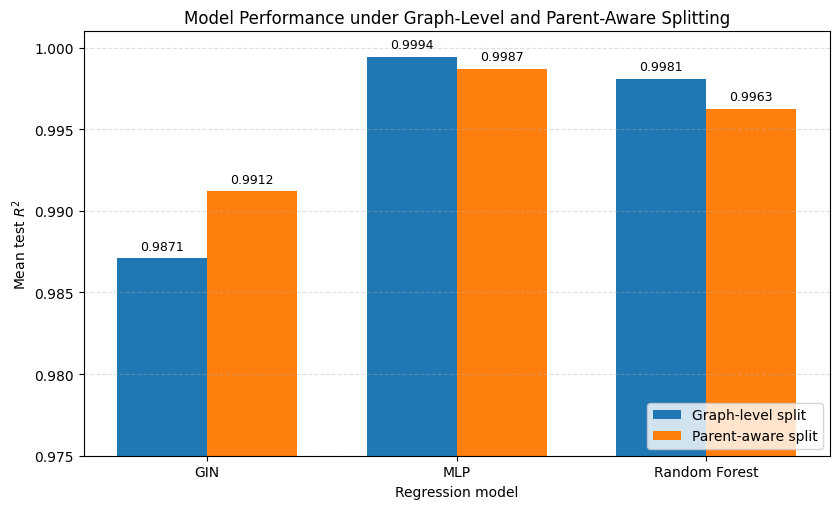

Figure saved to: /content/graph_level_parent_aware_comparison/results/figures/mean_r2_split_comparison.png
Vector figure saved to: /content/graph_level_parent_aware_comparison/results/figures/mean_r2_split_comparison.pdf

Mean R2 comparison figure created successfully.


In [ ]:
# =====================================================
# STEP 32: Mean R2 comparison figure
# =====================================================

import matplotlib.pyplot as plt


figure_data = (
    r2_publication_table[
        [
            "strategy",
            "model",
            "Mean_R2",
        ]
    ]
    .pivot(
        index="model",
        columns="strategy",
        values="Mean_R2",
    )
    .reindex(
        [
            "GIN",
            "MLP",
            "Random Forest",
        ]
    )
)

x_positions = np.arange(
    len(figure_data.index)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)

graph_level_bars = ax.bar(
    x_positions - bar_width / 2,
    figure_data["graph_level"],
    width=bar_width,
    label="Graph-level split",
)

parent_aware_bars = ax.bar(
    x_positions + bar_width / 2,
    figure_data["parent_aware"],
    width=bar_width,
    label="Parent-aware split",
)

ax.set_xlabel("Regression model")
ax.set_ylabel(r"Mean test $R^2$")
ax.set_title(
    "Model Performance under Graph-Level "
    "and Parent-Aware Splitting"
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    figure_data.index
)

ax.set_ylim(
    0.975,
    1.001,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

ax.legend(
    loc="lower right"
)


def add_bar_labels(
    bars,
):
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.4f}",
            xy=(
                bar.get_x()
                + bar.get_width() / 2,
                height,
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


add_bar_labels(
    graph_level_bars
)

add_bar_labels(
    parent_aware_bars
)

fig.tight_layout()

MEAN_R2_FIGURE_PNG = (
    RESULTS_DIR
    / "figures"
    / "mean_r2_split_comparison.png"
)

MEAN_R2_FIGURE_PDF = (
    RESULTS_DIR
    / "figures"
    / "mean_r2_split_comparison.pdf"
)

MEAN_R2_FIGURE_PNG.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    MEAN_R2_FIGURE_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    MEAN_R2_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    MEAN_R2_FIGURE_PNG,
)

print(
    "Vector figure saved to:",
    MEAN_R2_FIGURE_PDF,
)

print(
    "\nMean R2 comparison figure created "
    "successfully."
)

In [ ]:
# =====================================================
# STEP 33: Generate structural and split-composition
#          tables for the manuscript
# =====================================================

# -----------------------------------------------------
# 1. Structural characteristics
# -----------------------------------------------------

structural_data = pd.DataFrame({
    "Graph order": (
        df_descriptors["order"]
    ),
    "Number of edges": (
        df_descriptors["size"]
    ),
    "Maximum degree": (
        df_descriptors["maximum_degree"]
    ),
    "Degree variance": (
        df_descriptors["degree_std"] ** 2
    ),
    "Number of leaves": (
        df_descriptors["number_of_leaves"]
    ),
    "Diameter": (
        df_descriptors["diameter"]
    ),
    "Number of cycle nodes": (
        df_descriptors["number_of_cycle_nodes"]
    ),
})

structural_rows = []

for property_name in structural_data.columns:
    values = structural_data[
        property_name
    ].astype(float)

    structural_rows.append({
        "Property": property_name,
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Mean": values.mean(),
        "Standard deviation": values.std(
            ddof=1
        ),
        "Median": values.median(),
    })

structural_characteristics_table = (
    pd.DataFrame(structural_rows)
)


# -----------------------------------------------------
# 2. Split-composition table
# -----------------------------------------------------

def split_family_count(
    split_table,
    split_name,
    family_name,
):
    return int(
        (
            (
                split_table["split"]
                == split_name
            )
            &
            (
                split_table["family"]
                == family_name
            )
        ).sum()
    )


def split_total_count(
    split_table,
    split_name,
):
    return int(
        (
            split_table["split"]
            == split_name
        ).sum()
    )


graph_level_leaking_groups = int(
    leakage_audit.loc[
        leakage_audit["strategy"]
        == "graph_level",
        "leaking_groups",
    ].iloc[0]
)

parent_aware_leaking_groups = int(
    leakage_audit.loc[
        leakage_audit["strategy"]
        == "parent_aware",
        "leaking_groups",
    ].iloc[0]
)


split_composition_rows = [
    {
        "Category": "Training graphs",
        "Graph-level split": split_total_count(
            graph_level_table,
            "train",
        ),
        "Parent-aware split": split_total_count(
            parent_aware_table,
            "train",
        ),
    },
    {
        "Category": "Validation graphs",
        "Graph-level split": split_total_count(
            graph_level_table,
            "validation",
        ),
        "Parent-aware split": split_total_count(
            parent_aware_table,
            "validation",
        ),
    },
    {
        "Category": "Test graphs",
        "Graph-level split": split_total_count(
            graph_level_table,
            "test",
        ),
        "Parent-aware split": split_total_count(
            parent_aware_table,
            "test",
        ),
    },
    {
        "Category": "Training unicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "train",
            "unicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "train",
            "unicyclic",
        ),
    },
    {
        "Category": "Training bicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "train",
            "bicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "train",
            "bicyclic",
        ),
    },
    {
        "Category": "Validation unicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "validation",
            "unicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "validation",
            "unicyclic",
        ),
    },
    {
        "Category": "Validation bicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "validation",
            "bicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "validation",
            "bicyclic",
        ),
    },
    {
        "Category": "Test unicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "test",
            "unicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "test",
            "unicyclic",
        ),
    },
    {
        "Category": "Test bicyclic graphs",
        "Graph-level split": split_family_count(
            graph_level_table,
            "test",
            "bicyclic",
        ),
        "Parent-aware split": split_family_count(
            parent_aware_table,
            "test",
            "bicyclic",
        ),
    },
    {
        "Category": "Cross-split parent groups",
        "Graph-level split": (
            graph_level_leaking_groups
        ),
        "Parent-aware split": (
            parent_aware_leaking_groups
        ),
    },
]

split_composition_table = pd.DataFrame(
    split_composition_rows
)


# -----------------------------------------------------
# Save numerical tables
# -----------------------------------------------------

STRUCTURAL_TABLE_PATH = (
    RESULTS_DIR
    / "tables"
    / "paper_dataset_structural_characteristics.csv"
)

SPLIT_TABLE_PATH = (
    RESULTS_DIR
    / "tables"
    / "paper_split_composition.csv"
)

structural_characteristics_table.to_csv(
    STRUCTURAL_TABLE_PATH,
    index=False,
)

split_composition_table.to_csv(
    SPLIT_TABLE_PATH,
    index=False,
)


# -----------------------------------------------------
# Print manuscript-ready values
# -----------------------------------------------------

print(
    "Structural characteristics table:"
)

print(
    structural_characteristics_table.to_string(
        index=False,
        formatters={
            "Minimum": lambda x: f"{x:.2f}",
            "Maximum": lambda x: f"{x:.2f}",
            "Mean": lambda x: f"{x:.2f}",
            "Standard deviation": (
                lambda x: f"{x:.2f}"
            ),
            "Median": lambda x: f"{x:.2f}",
        },
    )
)

print(
    "\nSplit-composition table:"
)

print(
    split_composition_table.to_string(
        index=False
    )
)

print("\nSaved files:")
print(STRUCTURAL_TABLE_PATH)
print(SPLIT_TABLE_PATH)

assert len(
    structural_characteristics_table
) == 7

assert len(
    split_composition_table
) == 10

assert (
    parent_aware_leaking_groups == 0
)

print(
    "\nBoth manuscript tables generated "
    "successfully."
)

Structural characteristics table:
             Property Minimum Maximum  Mean Standard deviation Median
          Graph order    6.00   30.00 20.66               6.06  21.00
      Number of edges    6.00   31.00 21.16               6.07  22.00
       Maximum degree    2.00    9.00  4.23               0.93   4.00
      Degree variance    0.00    4.31  0.94               0.50   0.86
     Number of leaves    0.00   18.00  6.36               3.44   6.00
             Diameter    2.00   16.00  8.49               2.39   8.00
Number of cycle nodes    3.00   30.00 12.13               5.96  11.00

Split-composition table:
                   Category  Graph-level split  Parent-aware split
            Training graphs              13426               13452
          Validation graphs               2877                2867
                Test graphs               2877                2861
  Training unicyclic graphs               6602                6601
   Training bicyclic graphs               682